# TP 3 — Pipeline RAG complet : Basic + Advanced + Eval (+ Graph bonus)

**Jour 2 · Module RAG · Durée : 3 h**

---

## Objectifs

À l'issue de ce TP, vous serez capable de :

1. **Construire** un pipeline **Basic RAG** complet de bout en bout (loading → chunking → embeddings → indexation → retrieval → augmentation → génération) avec **LangChain pour la tuyauterie** et **Python pur pour l'orchestration**.
2. **Mettre en œuvre des techniques d'Advanced RAG** pour passer du prototype à un outil robuste : recherche hybride (BM25 + dense + RRF), Query Rewriting, Multi-Query, HyDE, re-ranking par cross-encoder.
3. **Évaluer** le pipeline avec **RAGas** (Faithfulness, Answer Relevancy, Context Precision/Recall) et le concept de **LLM-as-a-judge**, et inspecter les traces avec **LangSmith**.
4. **(Bonus)** Implémenter un pipeline **Graph RAG** sur le même corpus et le **comparer** au Vector RAG.

## Structure du notebook

| Partie | Durée | Contenu |
|--------|-------|---------|
| **A — Basic RAG (pipeline détaillé)** | 1 h 15 | Loading (LangChain loaders), Chunking (LangChain splitters + Contextual Retrieval), Embeddings (Bi-encoder + similarité), Vector Storage (Chroma + écosystème), Retrieval, Reranking, Génération |
| **B — Advanced RAG** | 45 min | Recherche hybride + RRF, Query Rewriting, Multi-Query, HyDE, *Lost in the Middle*, Cross-Encoder vs Bi-Encoder |
| **C — Évaluation & Observabilité** | 30 min | RAGas (Faithfulness, Answer Relevancy, Context Precision/Recall), LLM-as-a-judge, LangSmith |
| **D — Bonus : Graph RAG** | 30–45 min | Extraction entités/relations, graphe NetworkX, communautés, retrieval local/global, comparaison Vector vs Graph |

> **Parti pris pédagogique** — On utilise LangChain *uniquement* pour les **briques spécifiques** (loaders, splitters, vector stores). L'**orchestration globale est en Python pur** (pas de `Chain` ni de `PromptTemplate` complexe) pour garder une transparence totale sur le flux de données et sur ce qui est envoyé au LLM.

## Vue d'ensemble du pipeline RAG

```
┌────────────────  PHASE OFFLINE (Indexation)  ────────────────┐
│  Loading ─▶ Chunking ─▶ Embeddings ─▶ Vector Store + BM25     │
└────────────────────────────────────────────────────────────────┘
┌────────────────  PHASE ONLINE  (Génération)  ────────────────┐
│  Query Embed ─▶ Retrieval (hybrid + RRF) ─▶ Re-rank ─▶ LLM    │
└────────────────────────────────────────────────────────────────┘
```

> **Principe clé n°1 :** *La qualité de la réponse est bornée par la qualité du retrieval.* Un meilleur LLM ne compensera jamais un mauvais retrieval.
>
> **Principe clé n°2 :** *RAG vs Fine-Tuning ne s'opposent pas.* RAG **injecte de la connaissance** (fraîche, sourçable) ; le fine-tuning **apprend un comportement** (style, format). L'objection « les fenêtres de contexte géantes rendent RAG obsolète » ignore le **Needle in a Haystack**, le **coût** et la **latence** des longs contextes.

## Pourquoi RAG ? (rappel des lacunes des LLMs)

| Lacune du LLM seul | Comment RAG la corrige |
|---|---|
| **Hallucinations** sous incertitude | Ancrage factuel (*grounding*) sur du contexte vérifiable |
| **Knowledge cutoff** (données figées à l'entraînement) | Index mis à jour à la volée (re-indexation) |
| **Données privées** (entreprise, RGPD) inaccessibles | Indexation locale, contrôle des accès |
| **Pas de traçabilité** des affirmations | Citation des sources (chunk → document → page) |

## Outillage (tout open-source / gratuit)

| Outil | Rôle |
|-------|------|
| `langchain` + `langchain-community` | Loaders, splitters, intégration vector stores |
| `sentence-transformers` | Embeddings (bi-encodeur) + reranking (cross-encodeur) |
| `chromadb` | Base vectorielle in-memory |
| `rank_bm25` | Recherche sparse (mots-clés) |
| **`Llama-3.3-70B-Versatile` via API Groq** | LLM pour la génération, l'extraction et le LLM-as-a-judge |
| `ragas` | Évaluation RAG (Faithfulness, Context Precision/Recall, Answer Relevancy) |
| `langsmith` | Traçage et observabilité (optionnel, clé API requise) |
| `networkx` | Graphe de connaissances (Partie D bonus) |

> **Pourquoi Groq ?** API **gratuite** (tier free généreux), **OpenAI-compatible** (pattern réutilisable avec OpenAI / Azure / Anthropic), **inférence ultra-rapide** (LPU). Modèle utilisé ici : **`llama-3.3-70b-versatile`** (gratuit, 70B paramètres, excellent suivi d'instructions et JSON).
>
> **Obtenir une clé Groq (30 secondes)** :
> 1. Aller sur **https://console.groq.com**
> 2. Se connecter (Google / GitHub) — pas de carte bancaire requise
> 3. *API Keys → Create API Key* — copier la clé `gsk_...`

---


## 0. Préparation de l'environnement

In [1]:
# ─── Install dependencies (uncomment on Google Colab or first run) ──────────
# Core (loaders, splitters, vector store)
!pip install -q langchain langchain-community langchain-text-splitters
!pip install -q langchain-openai langchain-groq
!pip install -q chromadb sentence-transformers rank_bm25
!pip install -q pypdf pymupdf beautifulsoup4 requests

# Tokenizer + LLM (Groq via openai SDK)
!pip install -q tiktoken openai

# Évaluation et observabilité
!pip install -q ragas datasets
!pip install -q langsmith  # optionnel — clé API requise

# Visualisation et graphe (Partie D bonus)
!pip install -q networkx matplotlib seaborn scikit-learn

# ─── Bibliothèques d'extension mentionnées (NON requises pour ce TP) ───────
# Loaders avancés    : docling, unstructured, marker-pdf, firecrawl-py
# Chunking avancé    : chonkie               (semantic + agentic chunking)
# Reranker hosté     : cohere                (Cohere Rerank API)
# Reranker local     : FlagEmbedding         (BGE Reranker)
# Frameworks éval    : trulens-eval, deepeval

# ─── Configuration de la clé Groq ──────────────────────────────────────────
# Ce notebook utilise l'API Groq (compatible OpenAI) avec llama-3.3-70b-versatile.
# 1. Créer une clé gratuite sur :  https://console.groq.com
# 2. La copier ci-dessous OU l'exporter en variable d'environnement :
#       export GROQ_API_KEY="gsk_..."
# 3. Aucune carte bancaire requise — tier gratuit suffisant pour tout le TP.


In [ ]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["OBJC_DISABLE_INITIALIZE_FORK_SAFETY"] = "YES"
import json
import hashlib
import warnings
import textwrap
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI

warnings.filterwarnings('ignore')

# ─── Configuration Groq (API compatible OpenAI) ───────────────────────────
# Récupérer une clé gratuite sur : https://console.groq.com
GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "VOTRE_CLE_GROQ_ICI")
GROQ_BASE_URL = "https://api.groq.com/openai/v1"
LLM_MODEL = "llama-3.3-70b-versatile"

API_AVAILABLE = GROQ_API_KEY != "VOTRE_CLE_GROQ_ICI"

if API_AVAILABLE:
    llm_client = OpenAI(api_key=GROQ_API_KEY, base_url=GROQ_BASE_URL)
    try:
        # Smoke test
        resp = llm_client.chat.completions.create(
            model=LLM_MODEL,
            messages=[{"role": "user", "content": "ping"}],
            max_tokens=5,
        )
        print(f"Groq + {LLM_MODEL} ready.")
    except Exception as e:
        print(f"Groq API unreachable: {e}")
        API_AVAILABLE = False
else:
    llm_client = None
    print("Clé Groq absente. Définir GROQ_API_KEY ou éditer le notebook.")
    print("→ Les cellules LLM seront ignorées tant que la clé n'est pas configurée.")


Groq + llama-3.3-70b-versatile ready.


---

# PARTIE A — Vector RAG (1 h 15)

Construction d'un pipeline vectoriel complet depuis l'ingestion jusqu'à la génération, avec évaluation sur un golden set.

---

## Étape 1 — Loading (extraction des données)

> **Concept clé** — Le format source détermine 50 % de la qualité du retrieval. Un PDF mal extrait (texte cassé en colonnes, tableaux écrasés, en-têtes répétés) ruine **silencieusement** tout le pipeline en aval.

### 1.1 Le format roi : Markdown

Le **Markdown** est dit *« LLM-ready »* : il préserve la **hiérarchie sémantique** (titres `#`, listes, tableaux, code) qui sera ré-exploitée pour :
- le **chunking structurel** (un chunk = une section),
- les **métadonnées** (`section`, `chapter`),
- le **prompt** final (le LLM comprend nativement le Markdown).

**Règle d'or** : si vous le pouvez, **convertissez vos sources en Markdown propre à l'ingestion**, puis indexez le Markdown — pas le PDF brut.

### 1.2 Catalogue des loaders LangChain

LangChain propose une [intégration de loaders pour quasi tous les formats](https://docs.langchain.com/oss/python/integrations/document_loaders) — voici les plus pertinents :

| Source | Loader recommandé | Notes |
|---|---|---|
| **PDF simple** | `PyPDFLoader` | Rapide, page par page, gère bien le texte mono-colonne |
| **PDF complexe** (tableaux, multi-colonnes, scan) | `DoclingLoader` (IBM) | Excellent OCR + structure ; ou `UnstructuredLoader` (open) |
| **PDF → Markdown** | `Marker` ([VikParuchuri/marker](https://github.com/VikParuchuri/marker)) | Redoutable pour produire un Markdown propre depuis un PDF |
| **Web (HTML)** | `WebBaseLoader` | Simple, basé sur BeautifulSoup |
| **Web → Markdown** | `Firecrawl` ou [`Jina AI Reader`](https://jina.ai/reader) | Nettoyage, anti-bot, sortie Markdown structurée |
| **Markdown / Texte** | `TextLoader` / `UnstructuredMarkdownLoader` | Préserve la structure |
| **Office** (DOCX, PPTX) | `UnstructuredLoader` | Conversion homogène en `Document` |
| **Code source** | `GenericLoader` + `LanguageParser` | Splitting par fonction/classe |

### 1.3 La structure `Document` de LangChain

Tous les loaders renvoient une **liste uniforme** d'objets `Document(page_content: str, metadata: dict)`. Les **métadonnées** sont **critiques** :

- **filtrage au retrieval** : « uniquement les documents de 2024 », « uniquement la collection juridique »
- **attribution de sources** : permettre la citation `[doc.pdf, p.4]`
- **debugging** : remonter d'un mauvais chunk à sa source originale

> **Ouverture — Multimodal RAG** : les PDF de recherche contiennent **figures et tableaux** porteurs d'information. Les approches récentes (`ColPali`, `Qwen2-VL`, `LayoutLMv3`) embeddent **directement les pages comme images**, en complément du texte. À explorer pour les corpus scientifiques riches en tableaux/figures.


In [3]:
# ─── Imports : LangChain loaders + Document standard ──────────────────────
from langchain_core.documents import Document  # structure uniforme {page_content, metadata}
from langchain_community.document_loaders import (
    PyPDFLoader,                       # PDF simple (page-by-page)
    WebBaseLoader,                     # HTML / Web (basé sur BeautifulSoup)
    TextLoader,                        # Markdown / texte brut (zéro dépendance)
)

# Loaders avancés (à installer si besoin — non requis pour ce TP) :
#   pip install unstructured           → UnstructuredMarkdownLoader, UnstructuredPDFLoader
#   pip install langchain-docling      → DoclingLoader (IBM, PDF complexes)
#   pip install firecrawl-py           → FireCrawlLoader

import hashlib
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Dict


# ─── Helper : ajouter un identifiant court à chaque Document ──────────────
def with_doc_id(doc: Document) -> Document:
    """Attache un id court (8 hex chars) calculé sur le contenu."""
    if "doc_id" not in doc.metadata:
        doc.metadata["doc_id"] = hashlib.md5(doc.page_content[:200].encode()).hexdigest()[:8]
    return doc


# ─── Wrappers fins autour des loaders LangChain ───────────────────────────
def load_pdf(path: str) -> List[Document]:
    """Charge un PDF page par page (PyPDFLoader)."""
    docs = PyPDFLoader(path).load()
    for d in docs:
        d.metadata["format"] = "pdf"
        d.metadata["source"] = Path(path).name
        with_doc_id(d)
    return docs


def load_markdown(path: str) -> List[Document]:
    """Charge un fichier Markdown via TextLoader (la structure MD sera exploitée
    plus tard par MarkdownHeaderTextSplitter — ici on charge en texte brut)."""
    docs = TextLoader(path, encoding="utf-8").load()
    for d in docs:
        d.metadata["format"] = "markdown"
        d.metadata["source"] = Path(path).name
        with_doc_id(d)
    return docs


def load_web(url: str) -> List[Document]:
    """Charge une page web (WebBaseLoader)."""
    docs = WebBaseLoader(url).load()
    for d in docs:
        d.metadata["format"] = "web"
        d.metadata["source"] = url
        with_doc_id(d)
    return docs


print("LangChain loaders prêts : PDF, Markdown, Web.")
print("Type retourné : List[langchain_core.documents.Document]")


USER_AGENT environment variable not set, consider setting it to identify your requests.


LangChain loaders prêts : PDF, Markdown, Web.
Type retourné : List[langchain_core.documents.Document]


### 1.1 Création d'un corpus d'exemple

Pour ce TP, nous créons un petit corpus de documents sur l'**Intelligence Artificielle** issus de plusieurs sources. Cela simule un scénario réel où la connaissance métier est dispersée entre différents formats.

In [4]:
# ── Create sample Markdown documents ──────────────────────────────────────
# We simulate a multi-document corpus about AI topics

sample_docs_dir = Path("sample_data")
sample_docs_dir.mkdir(exist_ok=True)

# Document 1: Transformer Architecture
(sample_docs_dir / "transformers.md").write_text("""\
# Transformer Architecture

## Overview
The Transformer architecture was introduced by Vaswani et al. in the 2017 paper
"Attention Is All You Need". It replaced recurrent neural networks (RNNs) with
self-attention mechanisms, enabling parallel processing of sequences.

The key innovation is scaled dot-product attention, which computes attention
weights between all pairs of tokens simultaneously. This allows capturing
long-range dependencies without the vanishing gradient problem.

## Self-Attention Mechanism
Self-attention computes three matrices from the input: Query (Q), Key (K), and
Value (V). The attention output is computed as softmax(QK^T / sqrt(d_k)) * V.

Multi-head attention runs multiple attention operations in parallel, each with
different learned projections. This allows the model to attend to information
from different representation subspaces at different positions.

## Encoder-Decoder Structure
The original Transformer has an encoder-decoder structure. The encoder processes
the input sequence bidirectionally. The decoder generates the output sequence
autoregressively, attending to both its own previous outputs and the encoder's
representations via cross-attention.

Modern variants include encoder-only models (BERT), decoder-only models (GPT),
and encoder-decoder models (T5, BART).

## Positional Encoding
Since self-attention is permutation-invariant, positional information must be
injected explicitly. The original paper uses sinusoidal positional encodings.
Modern models often use learned positional embeddings or relative position
encodings like RoPE (Rotary Position Embedding) and ALiBi.
""", encoding="utf-8")

# Document 2: RAG Systems
(sample_docs_dir / "rag_systems.md").write_text("""\
# Retrieval-Augmented Generation

## Definition
Retrieval-Augmented Generation (RAG) combines an information retrieval layer with
a language model so that responses are generated from retrieved evidence instead
of relying only on parametric memory. The canonical paper by Lewis et al. (2020)
introduced this paradigm for knowledge-intensive NLP tasks.

RAG systems split knowledge into parametric memory (model weights, frozen at
training time) and non-parametric memory (document index, updatable at any time).

## Why RAG Matters
Pure LLMs suffer from knowledge cutoff, hallucinations under uncertainty, and
inability to access private enterprise data. RAG addresses these by grounding
generation in retrieved evidence, enabling source attribution and freshness.

In production, RAG reduces hallucination rates by 40-60% compared to vanilla
LLM prompting, according to industry benchmarks.

## Chunking Strategies
Chunking is the most underestimated quality lever in RAG. Strategies include:
- Fixed-size (token-based): window of 256-512 tokens with 10-20% overlap
- Recursive splitting: split by hierarchical separators (paragraphs, sentences)
- Semantic chunking: segment by embedding similarity between adjacent passages
- Document-aware: respect document structure (headings, sections, code blocks)

The optimal chunk size depends on the use case: smaller chunks (256 tokens) favor
precision, while larger chunks (1024 tokens) preserve more context.

## Hybrid Retrieval
Hybrid retrieval combines sparse methods (BM25/TF-IDF for exact keyword matching)
with dense methods (embedding similarity for semantic matching). Results are fused
using Reciprocal Rank Fusion (RRF). This is the recommended approach for
production systems as it balances recall and robustness.

## Evaluation
RAG evaluation requires both component-level and end-to-end metrics:
- Retrieval: Recall@k, Hit Rate, MRR, nDCG
- Generation: Faithfulness, Answer Relevancy (via Ragas framework)
- Context: Context Precision, Context Recall
- Operations: latency p50/p95, cost per query, fallback rate
""", encoding="utf-8")

# Document 3: LLM Fine-tuning
(sample_docs_dir / "finetuning.md").write_text("""\
# LLM Fine-Tuning

## When to Fine-Tune vs RAG
Fine-tuning modifies model weights to adapt behavior (tone, format, domain
language). RAG provides dynamic knowledge access. They are complementary:
- Need fresh knowledge → RAG
- Need specific behavior/style → Fine-tuning
- Need both → Hybrid (fine-tune for behavior + RAG for knowledge)

## LoRA and QLoRA
Low-Rank Adaptation (LoRA) freezes the pre-trained model and injects trainable
rank decomposition matrices into each Transformer layer. Instead of updating the
full weight matrix W, LoRA learns two small matrices A and B such that the update
is W + BA, where B has shape (d, r) and A has shape (r, d) with r << d.

QLoRA combines LoRA with 4-bit quantization of the base model, enabling
fine-tuning of 65B parameter models on a single 48GB GPU. This dramatically
reduces the hardware requirements for fine-tuning.

## RLHF and DPO
Reinforcement Learning from Human Feedback (RLHF) trains a reward model from
human preferences, then optimizes the LLM policy via PPO. Direct Preference
Optimization (DPO) simplifies this by directly optimizing preferences without
a separate reward model, using a classification loss on preference pairs.

## Evaluation of Fine-Tuned Models
Fine-tuned models should be evaluated on:
- Task-specific benchmarks (accuracy, F1, BLEU, ROUGE)
- Safety and alignment checks (TruthfulQA, toxicity)
- Catastrophic forgetting tests (performance on original capabilities)
- Human evaluation for subjective quality (fluency, helpfulness)
""", encoding="utf-8")

# Document 4: Vector Databases
(sample_docs_dir / "vector_databases.md").write_text("""\
# Vector Databases and Indexing

## Why Vector Databases
Vector databases store high-dimensional embeddings and enable fast approximate
nearest neighbor (ANN) search. Exact search has O(n) complexity, which is too
slow for millions of vectors. ANN algorithms trade a small amount of accuracy
for orders-of-magnitude speedup.

## HNSW Algorithm
Hierarchical Navigable Small World (HNSW) is the most popular ANN algorithm.
It builds a multi-layer graph where each layer is a navigable small-world network.
Search starts at the top layer (sparse, long-range connections) and progressively
refines through lower layers (dense, short-range connections).

HNSW provides excellent recall (>95%) with millisecond-level latency for
collections of millions of vectors. Key parameters are M (number of connections)
and efConstruction (build-time quality vs speed tradeoff).

## Popular Solutions
- Chroma: embedded/server mode, simple API, good for prototyping
- FAISS (Meta): library-level, extremely fast, GPU support, no native persistence
- Pinecone: managed cloud, serverless scaling, metadata filtering
- Weaviate: open-source, native hybrid search, GraphQL API
- Qdrant: open-source, advanced filtering, gRPC, production-ready
- Milvus: open-source, highly scalable, multi-index support

## Similarity Metrics
The three main metrics for vector similarity are:
- Cosine similarity: measures angle between vectors, insensitive to magnitude
- Dot product: cosine × norms, useful when magnitude encodes importance
- Euclidean distance: geometric distance, less common in RAG

Important: the similarity metric must match what the embedding model was trained
with. If the model uses cosine similarity during training, index with cosine.
""", encoding="utf-8")

print(f"Created {len(list(sample_docs_dir.glob('*.md')))} sample Markdown documents in {sample_docs_dir}/")

Created 4 sample Markdown documents in sample_data/


In [5]:
# ─── Ingestion du corpus complet ──────────────────────────────────────────
all_documents: List[Document] = []

# Markdown locaux (générés ci-dessus)
for md_file in sorted(sample_docs_dir.glob("*.md")):
    docs = load_markdown(str(md_file))
    all_documents.extend(docs)
    print(f"  📄 {md_file.name}: {len(docs)} document(s)")

# Web (Wikipedia article on RAG)
try:
    web_url = "https://en.wikipedia.org/wiki/Retrieval-augmented_generation"
    web_docs = load_web(web_url)
    all_documents.extend(web_docs)
    print(f"  🌐 Wikipedia RAG article: {len(web_docs)} document(s)")
except Exception as e:
    print(f"  ⚠️  Web ingestion skipped (no internet?): {e}")

# PDF (Attention Is All You Need, original Transformer paper)
for pdf_file in sorted(sample_docs_dir.glob("*.pdf")):
    docs = load_pdf(str(pdf_file))
    all_documents.extend(docs)
    print(f"  📕 {pdf_file.name}: {len(docs)} page(s)")

print(f"\nTotal documents ingérés : {len(all_documents)}")
for doc in all_documents:
    src = doc.metadata.get("source", "?")
    fmt = doc.metadata.get("format", "?")
    print(f"  [{doc.metadata['doc_id']}] {src} | format={fmt} | {len(doc.page_content)} chars")


  📄 finetuning.md: 1 document(s)
  📄 rag_systems.md: 1 document(s)
  📄 transformers.md: 1 document(s)
  📄 vector_databases.md: 1 document(s)
  🌐 Wikipedia RAG article: 1 document(s)
  📕 AttentionIsAllYouNeed.pdf: 15 page(s)

Total documents ingérés : 20
  [332d3187] finetuning.md | format=markdown | 1513 chars
  [25e18dd4] rag_systems.md | format=markdown | 2072 chars
  [72cbf886] transformers.md | format=markdown | 1631 chars
  [d7083f28] vector_databases.md | format=markdown | 1727 chars
  [c41f7b68] https://en.wikipedia.org/wiki/Retrieval-augmented_generation | format=web | 24804 chars
  [7427f46a] AttentionIsAllYouNeed.pdf | format=pdf | 2860 chars
  [4fb501c9] AttentionIsAllYouNeed.pdf | format=pdf | 4258 chars
  [13ee450e] AttentionIsAllYouNeed.pdf | format=pdf | 1827 chars
  [e6638005] AttentionIsAllYouNeed.pdf | format=pdf | 2508 chars
  [e9c98ecf] AttentionIsAllYouNeed.pdf | format=pdf | 3199 chars
  [ba8a5b62] AttentionIsAllYouNeed.pdf | format=pdf | 3477 chars
  [d8898314] A

## Étape 2 — Chunking (découpage)

> **Concept clé** — Le chunking est le **levier qualité n°1** d'un pipeline RAG. C'est aussi le plus sous-estimé.

### 2.1 Pourquoi découper ?

| Raison | Explication |
|---|---|
| **Context window** | Un LLM a une fenêtre limitée — on ne peut pas y injecter un livre entier |
| **Granularité du retrieval** | Un chunk doit être **autonome** (compréhensible seul) et **focalisé** (un sujet) |
| **Coût / latence** | Moins de tokens en contexte = réponse plus rapide et moins chère |
| **Précision sémantique** | Un embedding capture la moyenne d'un chunk : trop long → moyenne floue |

### 2.2 Les paramètres : `chunk_size` et `chunk_overlap`

- **`chunk_size`** : taille cible (en tokens ou caractères). Compromis classique :
  - **128–256 tokens** → précision maximale, retrieval ciblé, mais contexte fragmenté
  - **512–1024 tokens** → contexte plus riche, mais plus de bruit
  - **> 2048 tokens** → utile uniquement pour des documents très denses

- **`chunk_overlap`** : redondance (tokens partagés entre chunks adjacents) pour éviter de **couper en plein milieu** d'une idée. Typique : **10–20 % de `chunk_size`**.

```
Document : "...phrase A. phrase B. phrase C. phrase D..."
chunk_size=20, overlap=5
┌────────────────┐
│ phrase A.      │  ── chunk 1
│ phrase B.      │
└──┬─────────────┘
   │ overlap (5)
┌──┴─────────────┐
│ phrase B.      │  ── chunk 2
│ phrase C.      │
└────────────────┘
```

### 2.3 Stratégies de chunking

| Stratégie | Principe | Quand l'utiliser |
|---|---|---|
| **Caractère/token fixe** | Fenêtre glissante de `N` tokens | Baseline, corpus homogène |
| **Récursif** | Coupe par `\n\n`, puis `\n`, puis `. `, puis ` ` | **Défaut recommandé** (LangChain) |
| **Structure-aware** | Respecte titres Markdown / balises HTML | Docs structurés (techniques, légaux) |
| **Semantic chunking** | Coupe quand la similarité d'embeddings adjacents chute | Coupes naturelles entre sujets |
| **Agentic chunking** | Un LLM décide où couper (ex. par concept) | Très haute qualité, coût élevé |

> **À explorer — la bibliothèque [`Chonkie`](https://github.com/chonkie-inc/chonkie)** réunit ces stratégies avancées (`SemanticChunker`, `AgenticChunker`, `LateChunker`) avec une API unifiée.

### 2.4 Enrichissement par métadonnées (CRITIQUE)

Chaque chunk **doit** porter ses métadonnées d'origine :
- `source` (nom de fichier / URL)
- `page` ou `section` (pour la citation)
- `chunk_index`, `chunk_strategy`
- métadonnées métier : `date`, `author`, `category`, `confidentiality`

Ces métadonnées permettent :
1. le **filtrage** au retrieval (`where={"category": "legal"}`)
2. l'**attribution** dans la réponse générée
3. le **debugging** (rapprocher un mauvais résultat de sa source)

### 2.5 Contextual Retrieval (Anthropic, 2024)

> **Idée** — Un chunk extrait isolément perd souvent son contexte global. *Exemple : « Le ROI a augmenté de 12 % » — mais de quelle entreprise, quelle année ?*

**Recette** : avant l'embedding, demander à un LLM de **préfixer chaque chunk** d'un court résumé de la section parente :

```
Original chunk    : "Le ROI a augmenté de 12 % au T3."
Contextualisé     : "[Acme Corp · Rapport annuel 2024 · Performance financière]
                     Le ROI a augmenté de 12 % au T3."
```

**Effet mesuré** par Anthropic : **−49 %** sur le taux d'échec du retrieval (et **−67 %** combiné avec un reranker). Coût : un appel LLM par chunk à l'indexation (faisable car offline).


In [6]:
# ─── Splitters LangChain : recommandés en production ──────────────────────
from langchain_text_splitters import (
    RecursiveCharacterTextSplitter,    # défaut récursif (caractères)
    MarkdownHeaderTextSplitter,        # respecte la hiérarchie Markdown
)

# Pour compter les tokens (modèle compatible GPT-4 / text-embedding-3)
import tiktoken
enc = tiktoken.get_encoding("cl100k_base")
def count_tokens(text: str) -> int:
    return len(enc.encode(text))


# Hyperparamètres du chunking
CHUNK_SIZE = 500         # tokens cibles
CHUNK_OVERLAP = 50       # 10 % d\'overlap → préserve le contexte aux frontières

# ─── Splitter 1 : récursif basé sur les TOKENS ────────────────────────────
# Principe : tente de couper sur \n\n, puis \n, puis ". ", puis " "
# `from_tiktoken_encoder` garantit que `chunk_size` est en TOKENS (pas caractères)
recursive_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="cl100k_base",
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ". ", " ", ""],   # ordre de préférence
)

# ─── Splitter 2 : structure Markdown (préserve la hiérarchie des titres) ──
# Chaque chunk porte en métadonnée les titres parents (h1, h2, h3)
header_splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=[("#", "h1"), ("##", "h2"), ("###", "h3")],
    strip_headers=False,
)


def chunk_documents(docs, splitter=recursive_splitter):
    """Applique un splitter LangChain à une liste de Documents.

    Renvoie une nouvelle liste de Documents avec :
    - le contenu découpé
    - les métadonnées propagées + chunk_index + chunk_strategy + chunk_id unique
    """
    out = []
    for doc in docs:
        sub_chunks = splitter.split_documents([doc])
        source = doc.metadata.get("source", "doc")
        for i, c in enumerate(sub_chunks):
            # ID déterministe et unique : combine source + index + hash du contenu
            # (le hash sur les 100 premiers chars seuls cause des collisions sur
            #  les pages PDF avec en-têtes/pieds de page identiques)
            id_seed = f"{source}|{i}|{c.page_content}"
            chunk_hash = hashlib.md5(id_seed.encode()).hexdigest()[:10]
            c.metadata = {
                **doc.metadata,
                **c.metadata,
                "chunk_index": i,
                "chunk_strategy": splitter.__class__.__name__,
                "chunk_id": chunk_hash,
            }
        out.extend(sub_chunks)
    return out


print("Splitters LangChain prêts :")
print(f"  • RecursiveCharacterTextSplitter (token-based, size={CHUNK_SIZE}, overlap={CHUNK_OVERLAP})")
print(f"  • MarkdownHeaderTextSplitter (structure-aware)")


Splitters LangChain prêts :
  • RecursiveCharacterTextSplitter (token-based, size=500, overlap=50)
  • MarkdownHeaderTextSplitter (structure-aware)


In [7]:
# ─── Application du chunking récursif sur tout le corpus ──────────────────
all_chunks = chunk_documents(all_documents, splitter=recursive_splitter)

print(f"Chunks créés : {len(all_chunks)}")
sizes = [count_tokens(c.page_content) for c in all_chunks]
print(f"Taille moyenne : {np.mean(sizes):.0f} tokens")
print(f"Min / Max : {min(sizes)} / {max(sizes)} tokens")

# Affichage de quelques chunks avec leurs métadonnées
print("\n--- Exemples de chunks ---")
for c in all_chunks:
    src = c.metadata.get("source", "?")
    idx = c.metadata.get("chunk_index", "?")
    print(f"\n[{c.metadata['chunk_id']}] source={src} | chunk #{idx} | {count_tokens(c.page_content)} tokens")
    print(textwrap.shorten(c.page_content, width=140, placeholder="..."))


Chunks créés : 49
Taille moyenne : 373 tokens
Min / Max : 3 / 495 tokens

--- Exemples de chunks ---

[9be097ac52] source=finetuning.md | chunk #0 | 357 tokens
# LLM Fine-Tuning ## When to Fine-Tune vs RAG Fine-tuning modifies model weights to adapt behavior (tone, format, domain language). RAG...

[d90eefa234] source=rag_systems.md | chunk #0 | 436 tokens
# Retrieval-Augmented Generation ## Definition Retrieval-Augmented Generation (RAG) combines an information retrieval layer with a...

[7da2f600a1] source=transformers.md | chunk #0 | 323 tokens
# Transformer Architecture ## Overview The Transformer architecture was introduced by Vaswani et al. in the 2017 paper "Attention Is All...

[add2fb47ea] source=vector_databases.md | chunk #0 | 366 tokens
# Vector Databases and Indexing ## Why Vector Databases Vector databases store high-dimensional embeddings and enable fast approximate...

[dc149a3da8] source=https://en.wikipedia.org/wiki/Retrieval-augmented_generation | chunk #0 | 342 toke

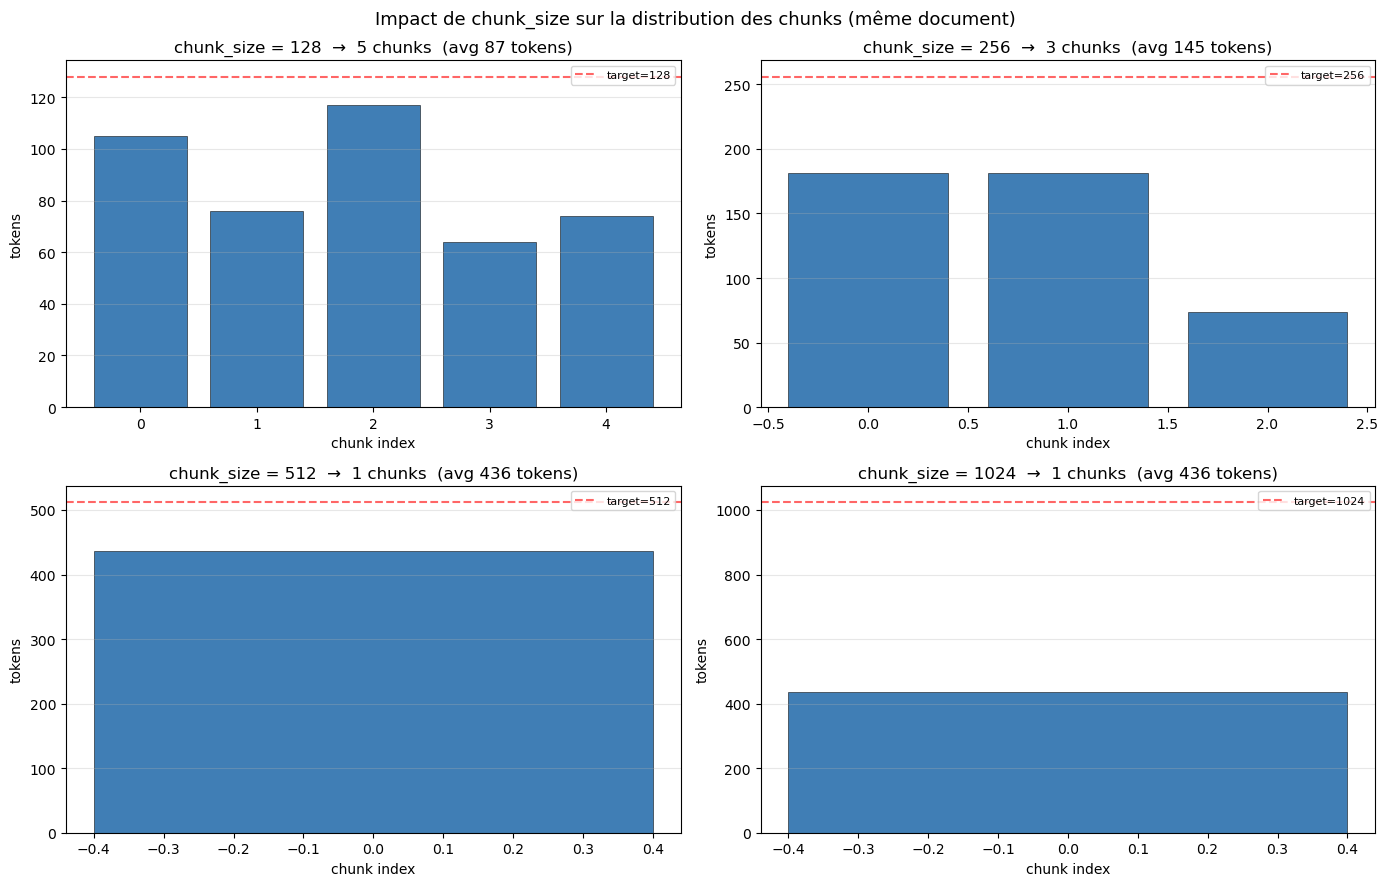

Lecture : plus chunk_size augmente, moins on a de chunks mais chacun est plus long.
Trop petit → contexte fragmenté ; trop grand → embedding flou et bruit au retrieval.


In [8]:
# ─── Comparaison visuelle : impact de chunk_size sur le découpage ─────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
test_sizes = [128, 256, 512, 1024]

sample_doc = all_documents[1]  # un document de référence

for ax, cs in zip(axes.flat, test_sizes):
    splitter_n = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
        encoding_name="cl100k_base",
        chunk_size=cs,
        chunk_overlap=int(cs * 0.1),
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    sub = splitter_n.split_documents([sample_doc])
    sizes_n = [count_tokens(c.page_content) for c in sub]
    ax.bar(range(len(sizes_n)), sizes_n, color="#00539C", alpha=0.75,
           edgecolor="black", linewidth=0.5)
    ax.axhline(y=cs, color="red", linestyle="--", alpha=0.6, label=f"target={cs}")
    ax.set_title(f"chunk_size = {cs}  →  {len(sub)} chunks  (avg {np.mean(sizes_n):.0f} tokens)")
    ax.set_xlabel("chunk index")
    ax.set_ylabel("tokens")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Impact de chunk_size sur la distribution des chunks (même document)",
             fontsize=13)
plt.tight_layout()
plt.show()

print("Lecture : plus chunk_size augmente, moins on a de chunks mais chacun est plus long.")
print("Trop petit → contexte fragmenté ; trop grand → embedding flou et bruit au retrieval.")


### 2.6 Démo : chunking structure-aware (Markdown)

`MarkdownHeaderTextSplitter` ne coupe **pas par tokens** : il découpe au **changement de titre**. Chaque chunk hérite alors de ses titres parents en métadonnées (`h1`, `h2`, `h3`) — utile pour reconstruire le contexte hiérarchique au moment du prompt.

**Pattern de production** : combiner les deux étages — d'abord `MarkdownHeaderTextSplitter` (préserve la structure), puis `RecursiveCharacterTextSplitter` sur chaque section trop longue (respecte `chunk_size`).


In [9]:
# ─── Démo MarkdownHeaderTextSplitter sur un fichier MD ────────────────────
md_path = sample_docs_dir / "rag_systems.md"
md_text = md_path.read_text(encoding="utf-8")

header_chunks = header_splitter.split_text(md_text)
print(f"{len(header_chunks)} chunks structurels (un par section)")
for hc in header_chunks:
    headers = " > ".join(v for k, v in hc.metadata.items() if k.startswith("h"))
    print(f"\n[{headers}]  ({count_tokens(hc.page_content)} tokens)")
    print(textwrap.shorten(hc.page_content, width=140, placeholder="..."))

# Pattern de production : MarkdownHeaderTextSplitter ▶ puis RecursiveCharacterTextSplitter
# pour respecter chunk_size sur les sections trop longues
combined_chunks = recursive_splitter.split_documents(header_chunks)
print(f"\nAprès second étage récursif : {len(combined_chunks)} chunks finaux")


5 chunks structurels (un par section)

[Retrieval-Augmented Generation > Definition]  (106 tokens)
# Retrieval-Augmented Generation ## Definition Retrieval-Augmented Generation (RAG) combines an information retrieval layer with a...

[Retrieval-Augmented Generation > Why RAG Matters]  (77 tokens)
## Why RAG Matters Pure LLMs suffer from knowledge cutoff, hallucinations under uncertainty, and inability to access private enterprise...

[Retrieval-Augmented Generation > Chunking Strategies]  (118 tokens)
## Chunking Strategies Chunking is the most underestimated quality lever in RAG. Strategies include: - Fixed-size (token-based): window...

[Retrieval-Augmented Generation > Hybrid Retrieval]  (64 tokens)
## Hybrid Retrieval Hybrid retrieval combines sparse methods (BM25/TF-IDF for exact keyword matching) with dense methods (embedding...

[Retrieval-Augmented Generation > Evaluation]  (74 tokens)
## Evaluation RAG evaluation requires both component-level and end-to-end metrics: - Retrieva

### 2.7 Démo : Contextual Retrieval (préfixage par LLM)

On construit pour chaque chunk un **court préfixe contextuel** généré par le LLM, qui résume **où** le chunk se situe dans le document parent. Ce préfixe est concaténé avant l'embedding et avant l'indexation.

**Coût** : 1 appel LLM par chunk (offline). **Bénéfice** : retrieval significativement plus robuste sur les corpus où les chunks isolés sont ambigus (rapports, contrats, transcripts).


In [10]:
# ─── Contextual Retrieval : préfixage de chaque chunk par un résumé contextuel ─
CONTEXTUAL_PROMPT = """<document>
{document}
</document>

Voici un chunk extrait de ce document :
<chunk>
{chunk}
</chunk>

Donne UNIQUEMENT un court contexte (1-2 phrases, max 50 tokens) qui situe ce chunk dans le document global, pour améliorer la recherche. Pas d'introduction, pas de formatage."""


def contextualize_chunk(chunk_text: str, parent_text: str, model: str = LLM_MODEL) -> str:
    """Renvoie le chunk préfixé d'un court contexte généré par LLM (Groq)."""
    if not API_AVAILABLE:
        return chunk_text
    try:
        resp = llm_client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": CONTEXTUAL_PROMPT.format(
                document=parent_text[:4000], chunk=chunk_text)}],
            temperature=0.0,
            max_tokens=80,
        )
        ctx = resp.choices[0].message.content.strip()
        return f"[Contexte: {ctx}]\n\n{chunk_text}"
    except Exception:
        return chunk_text


# Démo sur 2 chunks (l'opération est coûteuse → on ne contextualise pas tout le corpus ici)
parent = all_documents[1].page_content  # rag_systems.md
sample_chunks = [c for c in all_chunks if c.metadata.get("source") == "rag_systems.md"][:2]

print("=== Avant Contextual Retrieval ===")
for c in sample_chunks:
    snippet = textwrap.shorten(c.page_content, width=200, placeholder='...')
    print(f"\n• {snippet}")

print("\n=== Après Contextual Retrieval ===")
for c in sample_chunks:
    enriched = contextualize_chunk(c.page_content, parent)
    snippet = textwrap.shorten(enriched, width=300, placeholder='...')
    print(f"\n• {snippet}")

print("\nNote : pour ce TP on n'applique PAS la contextualisation à tout le corpus")
print("(coût LLM × N chunks). En production, c'est un job offline avant indexation.")


=== Avant Contextual Retrieval ===

• # Retrieval-Augmented Generation ## Definition Retrieval-Augmented Generation (RAG) combines an information retrieval layer with a language model so that responses are generated from retrieved...

=== Après Contextual Retrieval ===

• [Contexte: Ce chunk est le texte complet du document sur Retrieval-Augmented Generation, qui présente les concepts clés et les stratégies de cette approche pour les tâches de traitement du langage naturel. Il semble être le texte source lui-même.] # Retrieval-Augmented Generation ## Definition...

Note : pour ce TP on n'applique PAS la contextualisation à tout le corpus
(coût LLM × N chunks). En production, c'est un job offline avant indexation.


## Étape 3 — Embeddings (représentation vectorielle)

> **Concept clé** — Un *embedding* est une fonction $f : \text{texte} \to \mathbb{R}^d$ qui projette un texte dans un espace vectoriel où la **proximité géométrique reflète la proximité sémantique**.

### 3.1 Bi-encoder (modèle utilisé en RAG)

En RAG, on utilise typiquement des **Bi-encoders** : le **même modèle** encode indépendamment :
- chaque chunk **à l'indexation** (offline) → vecteur stocké
- la requête **à l'inférence** (online) → vecteur comparé

```
Chunk    ──▶ [ Encoder f ] ──▶ vecteur c ∈ ℝᵈ   (calculé une fois)
Requête  ──▶ [ Encoder f ] ──▶ vecteur q ∈ ℝᵈ   (calculé à chaque appel)
                                    │
                                    ▼
                              sim(q, c)  ──▶  top-k
```

> **Important** — Le **même modèle** doit être utilisé à l'indexation et à la requête. Changer de modèle d'embedding **invalide tout l'index** : il faut tout ré-embedder.

À comparer avec le **Cross-encoder** utilisé pour le reranking (§ Étape 6) — qui prend `(query, chunk)` ensemble pour scorer, beaucoup plus précis mais beaucoup plus lent.

### 3.2 Métriques de similarité

Trois métriques principales pour comparer deux vecteurs $\mathbf{q}$ et $\mathbf{c}$ :

| Métrique | Formule | Propriétés |
|---|---|---|
| **Cosine similarity** | $\cos(\mathbf{q}, \mathbf{c}) = \dfrac{\mathbf{q} \cdot \mathbf{c}}{\|\mathbf{q}\| \, \|\mathbf{c}\|}$ | Insensible à la magnitude, ∈ [-1, 1] |
| **Dot product** | $\mathbf{q} \cdot \mathbf{c} = \sum_i q_i c_i$ | Sensible à la magnitude (utile si la norme code l'importance) |
| **Distance euclidienne (L2)** | $\|\mathbf{q} - \mathbf{c}\|_2 = \sqrt{\sum_i (q_i - c_i)^2}$ | Distance géométrique, peu utilisée en RAG |

> **Astuce production** — On **L2-normalise** systématiquement les vecteurs ($\|\mathbf{v}\| = 1$). Dans ce cas : **cosine = dot product** et **$L_2^2 = 2(1 - \cos)$**. Une seule métrique implémentée, trois interprétations équivalentes.

> **Cohérence avec l'entraînement** — La métrique choisie doit **correspondre à celle utilisée à l'entraînement du modèle**. La plupart des `sentence-transformers` sont entraînés en cosinus.

### 3.3 Choix d'un modèle d'embedding — le [MTEB Benchmark](https://huggingface.co/spaces/mteb/leaderboard)

**MTEB** (*Massive Text Embedding Benchmark*) est le leaderboard de référence : il évalue les modèles sur **56 datasets** dans 8 catégories (retrieval, classification, clustering, STS…). À consulter avant tout choix.

### 3.4 Critères de choix d'un modèle

| Critère | Pourquoi ça compte |
|---|---|
| **Multilingue** | Si votre corpus est en FR/AR/multi-langue, un modèle EN-only (ex. `all-MiniLM`) sous-performe |
| **Performance vs latence** | Modèle lourd (1B params) → meilleure qualité, mais latence × 10 |
| **Local vs API** | Local = gratuit + RGPD-friendly ; API = qualité top mais coût + dépendance |
| **Dimensions** ($d$) | Plus $d$ est grand, plus le modèle peut coder de nuance — mais l'index est plus lourd |
| **`max_input_tokens`** | **Doit être ≥ `chunk_size`** sinon votre chunk est tronqué silencieusement à l'embedding ! |
| **Taille du modèle** | Impacte la RAM et la vitesse à l'inférence |

### 3.5 Modèles open-source courants

| Modèle | Dimensions | `max_tokens` | Multilingue | Notes |
|---|---|---|---|---|
| `sentence-transformers/all-MiniLM-L6-v2` | 384 | 256 | ❌ EN | Rapide, léger, **bon défaut** |
| `sentence-transformers/all-mpnet-base-v2` | 768 | 384 | ❌ EN | +qualité, +lent |
| `intfloat/multilingual-e5-large` | 1024 | 512 | ✅ 100 langues | Excellent multilingue |
| `BAAI/bge-large-en-v1.5` | 1024 | 512 | ❌ EN | Top MTEB en open-source |
| `BAAI/bge-m3` | 1024 | 8192 | ✅ 100 langues | Long contexte + multilingue |
| `text-embedding-3-large` (OpenAI) | 3072 | 8191 | ✅ | Top qualité, payant |

Pour ce TP : `all-MiniLM-L6-v2` ($d=384$) — léger, rapide, sans clé API.


In [11]:
from sentence_transformers import SentenceTransformer

# Load a lightweight open-source embedding model
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

print(f"Model: all-MiniLM-L6-v2")
print(f"Embedding dimensions: {embed_model.get_sentence_embedding_dimension()}")
print(f"Max sequence length: {embed_model.max_seq_length}")

Model: all-MiniLM-L6-v2
Embedding dimensions: 384
Max sequence length: 256


### 3.6 Démo : l'espace vectoriel réagit-il bien à la sémantique ?

On embedde 3 phrases et on calcule les 3 métriques pour vérifier que l'espace vectoriel **rapproche** une phrase et sa paraphrase, et **éloigne** un sujet opposé.


In [12]:
# ─── Démo : similarité entre phrase / paraphrase / sujet opposé ───────────
from numpy.linalg import norm

phrase_a   = "A transformer model uses self-attention to capture long-range dependencies."
phrase_a2  = "Transformers leverage attention mechanisms to model relations across distant tokens."  # paraphrase
phrase_b   = "Tomato sauce is essential for a good pasta dish."  # sujet opposé

embs = embed_model.encode([phrase_a, phrase_a2, phrase_b], normalize_embeddings=False)
qa, qa2, qb = embs

def cosine(u, v): return float(np.dot(u, v) / (norm(u) * norm(v)))
def dot_p(u, v):  return float(np.dot(u, v))
def l2(u, v):     return float(norm(u - v))

pairs = [
    ("A vs paraphrase A'", qa, qa2),
    ("A vs sujet opposé B", qa, qb),
    ("paraphrase A' vs B", qa2, qb),
]

header = ("Pair", "cosine", "dot", "L2")
print(f"{header[0]:<28} {header[1]:>8}  {header[2]:>8}  {header[3]:>8}")
print("-" * 60)
for name, u, v in pairs:
    print(f"{name:<28} {cosine(u, v):>8.3f}  {dot_p(u, v):>8.3f}  {l2(u, v):>8.3f}")

print("\nLecture attendue :")
print("  • cosine élevé entre A et sa paraphrase  (≈ 0.7-0.9)")
print("  • cosine faible entre A et le sujet opposé  (≈ 0.1-0.3)")
print("  • L2 inverse : faible quand les phrases sont proches")


Pair                           cosine       dot        L2
------------------------------------------------------------
A vs paraphrase A'              0.689     0.689     0.789
A vs sujet opposé B             0.067     0.067     1.366
paraphrase A' vs B             -0.007    -0.007     1.419

Lecture attendue :
  • cosine élevé entre A et sa paraphrase  (≈ 0.7-0.9)
  • cosine faible entre A et le sujet opposé  (≈ 0.1-0.3)
  • L2 inverse : faible quand les phrases sont proches


In [13]:
# ─── Embedding de tous les chunks ─────────────────────────────────────────
chunk_texts = [c.page_content for c in all_chunks]
embeddings = embed_model.encode(chunk_texts, show_progress_bar=True, normalize_embeddings=True)

print(f"\nEmbeddings shape : {embeddings.shape}")
print(f"Chaque chunk est un vecteur de dimension {embeddings.shape[1]}.")
print(f"Vecteurs L2-normalisés → cosine similarity = dot product.")


Batches:   0%|          | 0/2 [00:00<?, ?it/s]


Embeddings shape : (49, 384)
Chaque chunk est un vecteur de dimension 384.
Vecteurs L2-normalisés → cosine similarity = dot product.


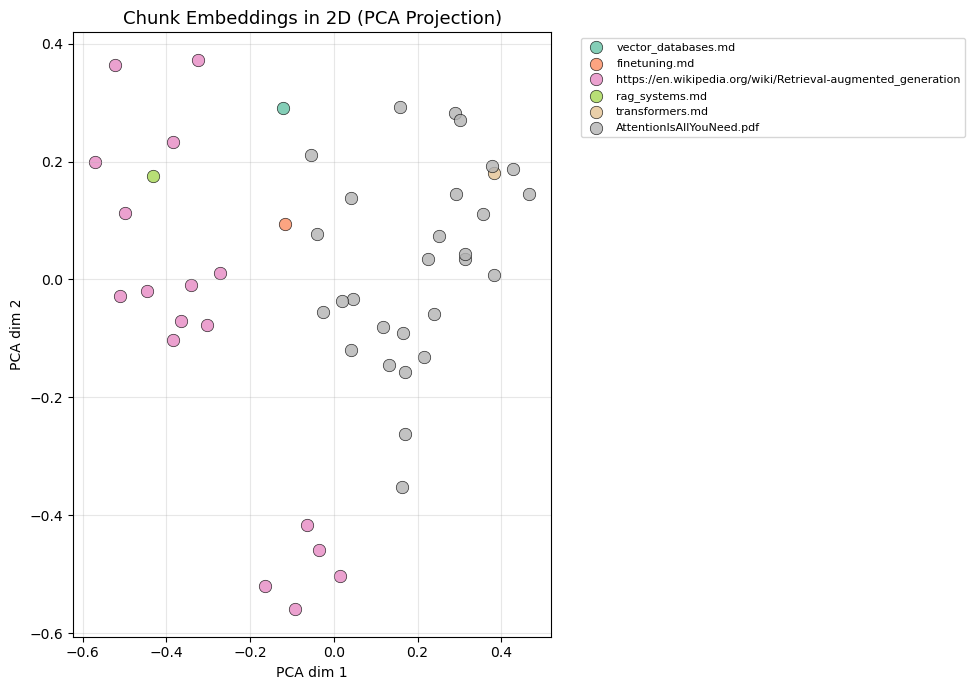

Chunks from the same document tend to cluster together in embedding space.
Thematically related chunks from different documents may also be close.


In [14]:
# ── Visualize embedding space ─────────────────────────────────────────────
# Use PCA to project 384D → 2D for visualization (safer on Apple Silicon than t-SNE)
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)

# Color by source document
sources = [c.metadata.get("source", "unknown") for c in all_chunks]
unique_sources = list(set(sources))
colors = plt.cm.Set2(np.linspace(0, 1, len(unique_sources)))
source_to_color = {s: colors[i] for i, s in enumerate(unique_sources)}

fig, ax = plt.subplots(figsize=(10, 7))
for source in unique_sources:
    mask = [s == source for s in sources]
    points = embeddings_2d[mask]
    ax.scatter(points[:, 0], points[:, 1], c=[source_to_color[source]],
               label=source, s=80, edgecolors="black", linewidth=0.5, alpha=0.8)

ax.set_title("Chunk Embeddings in 2D (PCA Projection)", fontsize=13)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
ax.set_xlabel("PCA dim 1")
ax.set_ylabel("PCA dim 2")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Chunks from the same document tend to cluster together in embedding space.")
print("Thematically related chunks from different documents may also be close.")


## Étape 4 — Vector Storage & Search Index

> **Concept clé** — Une recherche **exhaustive** (comparer la requête à *tous* les vecteurs) est en $\mathcal{O}(N \cdot d)$ : impraticable au-delà du million de vecteurs. On utilise donc des **index ANN** (*Approximate Nearest Neighbor*) qui sacrifient un peu de recall pour gagner des **ordres de grandeur** en latence.

### 4.1 Recherche exacte vs ANN

| Approche | Complexité | Recall | Quand l'utiliser |
|---|---|---|---|
| **Brute-force** (exact) | $\mathcal{O}(N \cdot d)$ par requête | 100 % | < 10 k vecteurs, ou benchmarks |
| **HNSW** (graphe) | $\mathcal{O}(\log N)$ | 95–99 % | Défaut production |
| **IVF** (clustering) | $\mathcal{O}(\sqrt{N})$ | 90–95 % | Très grands corpus, mémoire limitée |
| **PQ / OPQ** (quantification) | Combiné avec IVF | 80–90 % | Compression, milliards de vecteurs |

### 4.2 HNSW — *Hierarchical Navigable Small World*

Construit un **graphe multi-couches** :
- la couche du haut a **peu** de nœuds avec des liens **longs** (navigation rapide)
- les couches du bas ont **tous** les nœuds avec des liens **courts** (raffinement précis)

```
Layer 2  ●─────────────────────●          (sparse, long-range)
         │                     │
Layer 1  ●───●──────●───●──────●          (medium)
         │   │      │   │      │
Layer 0  ●─●─●─●─●─●─●─●─●─●─●─●          (dense, short-range)
```

La recherche descend de couche en couche en suivant le voisin le plus proche.

**Hyperparamètres clés** :
- `M` : nombre de connexions par nœud (typique : 16–64). $\uparrow M \Rightarrow$ +recall, +RAM
- `ef_construction` : qualité du graphe à la construction (typique : 100–400)
- `ef_search` : profondeur de recherche à la requête (typique : 50–200)

### 4.3 IVF — *Inverted File Index*

1. **k-means** sur les vecteurs → on obtient $K$ centroïdes (clusters).
2. À l'indexation : chaque vecteur est attaché à son centroïde le plus proche.
3. À la requête : on identifie les `n_probe` clusters les plus proches de $\mathbf{q}$, et on cherche **uniquement** dans ceux-là.

**Hyperparamètres** :
- `nlist` (= $K$) : nombre de clusters (typique : $\sqrt{N}$)
- `nprobe` : nombre de clusters explorés par requête (compromis recall/vitesse)

### 4.4 Comparaison HNSW vs IVF

| Critère | HNSW | IVF |
|---|---|---|
| Recall à latence égale | ✅ Meilleur | ⚠️ Inférieur |
| Empreinte mémoire | ❌ Lourde (graphe) | ✅ Légère |
| Insertion incrémentale | ✅ Rapide | ❌ Coûteuse (re-clustering) |
| Très grands corpus (>100M) | ⚠️ RAM-bound | ✅ Combiné avec PQ |

**Règle pratique** : commencer en **HNSW** ; passer à **IVF + PQ** uniquement si la mémoire devient un problème.

### 4.5 Écosystème des Vector DBs

| Vector DB | Type | Forces | Quand choisir |
|---|---|---|---|
| **FAISS** (Meta) | Bibliothèque (in-process) | Le plus rapide, GPU, large gamme d'index | Recherche, batch offline |
| **Chroma** | Embedded / serveur léger | API simple, démarrage instantané | **Prototypage, ce TP** |
| **Qdrant** | Serveur (Rust) | Excellent filtrage, gRPC, payloads riches | Production, RAG complexe |
| **Milvus** | Serveur distribué | Très scalable, multi-index, multi-tenant | Très gros corpus (≥ 100M) |
| **Pinecone** | Managed cloud | Serverless, zéro ops, filtrage métadonnées | Démarrage rapide, équipe ops réduite |
| **Weaviate** | Serveur, GraphQL | Hybride natif, modules ML intégrés | Hybride out-of-the-box |
| **pgvector** | Extension Postgres | Tout dans la DB existante | Stack PG existante, < 1M vecteurs |

> **Pour ce TP** — On utilise **Chroma** (in-memory, zéro install serveur, index HNSW intégré).


In [15]:
import chromadb
from rank_bm25 import BM25Okapi

# ─── Index vectoriel (ChromaDB) ────────────────────────────────────────────
chroma_client = chromadb.Client()  # in-memory pour ce TP

collection = chroma_client.create_collection(
    name="rag_lab",
    metadata={"hnsw:space": "cosine"}    # similarité cosinus (cf. § 3.3)
)

# Ajout des chunks dans Chroma — Chroma exige des metadata sérialisables
def _flatten_meta(m):
    return {k: (v if isinstance(v, (str, int, float, bool)) else str(v))
            for k, v in m.items()}

collection.add(
    ids=[c.metadata["chunk_id"] for c in all_chunks],
    embeddings=embeddings.tolist(),
    documents=chunk_texts,
    metadatas=[_flatten_meta(c.metadata) for c in all_chunks],
)

print(f"ChromaDB collection '{collection.name}' : {collection.count()} vecteurs")

# ─── Index BM25 (sparse) ───────────────────────────────────────────────────
tokenized_chunks = [text.lower().split() for text in chunk_texts]
bm25_index = BM25Okapi(tokenized_chunks)

print(f"Index BM25 : {len(tokenized_chunks)} documents indexés")


ChromaDB collection 'rag_lab' : 49 vecteurs
Index BM25 : 49 documents indexés


## Étape 5 — Retrieval top-k (recherche hybride + RRF)

> **Concept clé** — Aucune méthode de retrieval n'est universelle. Le **dense** comprend la sémantique mais peut rater un mot-clé exact. Le **sparse** (BM25) excelle en lexical mais ignore les paraphrases. La solution : **les combiner**.

### 5.1 Dense (vecteur) vs Sparse (BM25)

| Type | Forces | Faiblesses |
|---|---|---|
| **Dense** (cosinus sur embeddings) | Paraphrases, synonymes, langues, sens implicite | Mots rares (acronymes, codes produits, noms propres) |
| **Sparse** (BM25 / TF-IDF) | Mots-clés exacts, rapidité, interprétable | Synonymes, paraphrases, polysémie |
| **Hybride** | Le meilleur des deux | Plus de complexité (réglage RRF) |

### 5.2 Rappel formule BM25

Pour une requête $Q = \{q_1, \dots, q_n\}$ et un document $D$ :

$$
\text{BM25}(D, Q) = \sum_{i=1}^{n} \text{IDF}(q_i) \cdot \frac{f(q_i, D) \, (k_1 + 1)}{f(q_i, D) + k_1 \left(1 - b + b \cdot \dfrac{|D|}{\text{avgdl}}\right)}
$$

où $f(q_i, D)$ est la fréquence du terme dans $D$, $|D|$ la longueur du document, et $k_1, b$ des hyperparamètres ($k_1 \approx 1.5$, $b \approx 0.75$).

### 5.3 Reciprocal Rank Fusion (RRF)

On fusionne les classements en **ignorant les scores absolus** (qui ne sont pas comparables entre dense et sparse) — on n'utilise que **les rangs** :

$$
\text{RRF}(d) = \sum_{r \in \text{rankers}} \frac{1}{k + \text{rank}_r(d)}
$$

avec $k = 60$ (constante standard, lisse les contributions). Robuste, sans calibration, recommandé en production.


In [16]:
def retrieve_dense(query: str, top_k: int = 5):
    """Retrieval dense : similarité vectorielle (ChromaDB)."""
    query_embedding = embed_model.encode([query], normalize_embeddings=True).tolist()
    results = collection.query(
        query_embeddings=query_embedding,
        n_results=top_k,
        include=["documents", "metadatas", "distances"]
    )
    return [
        {"text": doc, "metadata": meta, "score": 1 - dist, "method": "dense"}
        for doc, meta, dist in zip(
            results["documents"][0], results["metadatas"][0], results["distances"][0]
        )
    ]


def retrieve_sparse(query: str, top_k: int = 5):
    """Retrieval sparse : BM25 (mots-clés)."""
    query_tokens = query.lower().split()
    scores = bm25_index.get_scores(query_tokens)
    top_indices = np.argsort(scores)[::-1][:top_k]
    return [
        {"text": all_chunks[i].page_content, "metadata": all_chunks[i].metadata,
         "score": scores[i], "method": "sparse"}
        for i in top_indices if scores[i] > 0
    ]


def retrieve_hybrid(query: str, top_k: int = 5, rrf_k: int = 60):
    """Retrieval hybride avec Reciprocal Rank Fusion (RRF)."""
    dense_results = retrieve_dense(query, top_k=top_k * 2)
    sparse_results = retrieve_sparse(query, top_k=top_k * 2)

    rrf_scores, doc_map = {}, {}
    for rank, r in enumerate(dense_results):
        key = r["text"][:100]
        rrf_scores[key] = rrf_scores.get(key, 0) + 1 / (rrf_k + rank + 1)
        doc_map[key] = r
    for rank, r in enumerate(sparse_results):
        key = r["text"][:100]
        rrf_scores[key] = rrf_scores.get(key, 0) + 1 / (rrf_k + rank + 1)
        doc_map[key] = r

    sorted_keys = sorted(rrf_scores, key=rrf_scores.get, reverse=True)[:top_k]
    return [{**doc_map[k], "score": rrf_scores[k], "method": "hybrid"} for k in sorted_keys]


print("Fonctions de retrieval définies : dense, sparse, hybrid (RRF).")


Fonctions de retrieval définies : dense, sparse, hybrid (RRF).


## Étape 6 — Re-ranking (cross-encoder)

> **Concept clé** — Le retrieval optimise la **couverture** (rappel) en récupérant 20–50 candidats. Le re-ranking optimise la **précision** en sélectionnant les 3–5 meilleurs grâce à un modèle plus puissant.

### 6.1 Bi-encoder vs Cross-encoder

C'est la distinction la plus importante de cette étape.

```
BI-ENCODER (utilisé en retrieval, § Étape 3)
    Query  ──▶ [ Encoder ] ──▶ q ∈ ℝᵈ
    Chunk  ──▶ [ Encoder ] ──▶ c ∈ ℝᵈ        score = sim(q, c)   (cosinus)

  ✓ Encode chaque chunk UNE SEULE FOIS (pré-calculé à l'indexation)
  ✓ Recherche en O(log N) via index ANN
  ✗ Pas d'attention CROISÉE entre la requête et le chunk

CROSS-ENCODER (utilisé en re-ranking)
    [ Query ; Chunk ]  ──▶ [ Encoder + Classifier ] ──▶ score ∈ ℝ

  ✓ Attention CROISÉE pleine entre les tokens de Q et ceux de C
    → bien plus précis (capture les nuances de la question)
  ✗ Doit re-passer le couple (Q, C) dans le modèle pour CHAQUE candidat
    → impraticable en retrieval (N candidats), parfait en re-ranking (k candidats)
```

### 6.2 Pipeline two-stage standard

```
Requête
   │
   ▼
[Retrieval]  ── 20-50 candidats ── (Bi-encoder + BM25, rapide)
   │
   ▼
[Reranking]  ── 3-5 meilleurs ── (Cross-encoder, lent mais précis)
   │
   ▼
Prompt LLM
```

**Gain typique** : +10 à +30 % sur la *Faithfulness* (sans changer le LLM de génération), pour quelques dizaines de millisecondes ajoutées.

### 6.3 Modèles de re-ranking courants

| Modèle | Type | Notes |
|---|---|---|
| `cross-encoder/ms-marco-MiniLM-L-6-v2` | Local, open | **Utilisé dans ce TP** — léger, rapide |
| `BAAI/bge-reranker-large` | Local, open | Top open-source, multilingue (`bge-reranker-v2-m3`) |
| **Cohere Rerank 3** | API hébergée | Très bonne qualité, API payante |
| `mixedbread-ai/mxbai-rerank-large-v1` | Local, open | Excellent, longue séquence |

> **Quand utiliser un re-ranking par LLM ?** Quand la nuance ou le raisonnement est nécessaire (juridique, médical, comparatif). Coût élevé : à réserver aux requêtes critiques.


In [17]:
from sentence_transformers import CrossEncoder

# Load cross-encoder reranker
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")


def rerank(query: str, results: List[Dict], top_k: int = 3) -> List[Dict]:
    """Rerank retrieved results using a cross-encoder."""
    if not results:
        return []
    pairs = [(query, r["text"]) for r in results]
    scores = reranker.predict(pairs)
    
    for r, score in zip(results, scores):
        r["rerank_score"] = float(score)
    
    reranked = sorted(results, key=lambda x: x["rerank_score"], reverse=True)
    return reranked[:top_k]


# ── Demonstrate reranking impact ──────────────────────────────────────────
query = "How does HNSW algorithm work for vector search?"
print(f"Query: '{query}'\n")

# Retrieve with hybrid
initial_results = retrieve_hybrid(query, top_k=8)
print("Before Reranking (Hybrid Retrieval):")
for i, r in enumerate(initial_results[:5]):
    print(f"  #{i+1} [{r['score']:.4f}] {textwrap.shorten(r['text'], width=90, placeholder='...')}")

# Rerank
reranked_results = rerank(query, initial_results, top_k=5)
print(f"\nAfter Reranking (Cross-Encoder):")
for i, r in enumerate(reranked_results[:5]):
    print(f"  #{i+1} [{r['rerank_score']:.4f}] {textwrap.shorten(r['text'], width=90, placeholder='...')}")

Query: 'How does HNSW algorithm work for vector search?'

Before Reranking (Hybrid Retrieval):
  #1 [0.0328] # Vector Databases and Indexing ## Why Vector Databases Vector databases store high-...
  #2 [0.0323] Performance improves by optimizing how vector similarities are calculated. Dot products...
  #3 [0.0308] RAG key stages[edit] Overview of RAG process, combining external documents and user...
  #4 [0.0294] output values. These are concatenated and once again projected, resulting in the final...
  #5 [0.0289] Chunking[edit] Chunking involves various strategies for breaking up the data into...

After Reranking (Cross-Encoder):
  #1 [5.9880] # Vector Databases and Indexing ## Why Vector Databases Vector databases store high-...
  #2 [-1.2275] Performance improves by optimizing how vector similarities are calculated. Dot products...
  #3 [-5.7390] Chunking[edit] Chunking involves various strategies for breaking up the data into...
  #4 [-6.3420] RAG key stages[edit] Overview of RAG 

## Étape 7 — Augmentation du prompt

L'augmentation insère les chunks récupérés dans un prompt template soigneusement conçu. Principes clés :

1. **Répondre UNIQUEMENT à partir du contexte fourni** — prévient les hallucinations
2. **Citer les sources** — permet la vérification et la confiance
3. **Repli explicite** — dire « preuves insuffisantes » plutôt que de deviner
4. **Structurer le contexte** — inclure les métadonnées (source, section) pour que le LLM sache d'où vient l'information

In [18]:
def build_rag_prompt(query: str, retrieved_chunks: List[Dict]) -> str:
    """Build a RAG prompt with retrieved context and citation instructions."""
    # Format context blocks with metadata
    context_blocks = []
    for i, chunk in enumerate(retrieved_chunks):
        source = chunk["metadata"].get("source", "unknown")
        section = chunk["metadata"].get("section", "")
        chunk_id = f"{source}:{section}" if section else source
        context_blocks.append(
            f"[Source {i+1}: {chunk_id}]\n{chunk['text']}"
        )

    context_str = "\n\n---\n\n".join(context_blocks)

    prompt = f"""You are an expert assistant. Answer the user's question using ONLY the provided context.

Rules:
- Answer ONLY from the provided context below.
- If the evidence is insufficient, say exactly: "Insufficient evidence in the provided context."
- Each factual claim must cite at least one source using [Source N] format.
- Be concise and direct.

Context:
{context_str}

Question: {query}

Answer:"""
    return prompt


# ── Build a prompt for our query ──────────────────────────────────────────
query = "What are the different chunking strategies for RAG and when should I use each?"
retrieved = retrieve_hybrid(query, top_k=5)
reranked = rerank(query, retrieved, top_k=3)

prompt = build_rag_prompt(query, reranked)
print(f"Prompt length: {count_tokens(prompt)} tokens\n")
print(prompt[:1500])
print("\n... [truncated for display]")

Prompt length: 1297 tokens

You are an expert assistant. Answer the user's question using ONLY the provided context.

Rules:
- Answer ONLY from the provided context below.
- If the evidence is insufficient, say exactly: "Insufficient evidence in the provided context."
- Each factual claim must cite at least one source using [Source N] format.
- Be concise and direct.

Context:
[Source 1: https://en.wikipedia.org/wiki/Retrieval-augmented_generation]
Chunking[edit]
Chunking involves various strategies for breaking up the data into vectors so the retriever can find details in it.


 Different data styles have patterns that correct chunking can take advantage of.
Three types of chunking strategies are:[citation needed]

Fixed length with overlap. This is fast and easy. Overlapping consecutive chunks helps to maintain semantic context across chunks.
Syntax-based chunks can break the document up into sentences. Libraries such as spaCy or NLTK can also help.
File format-based chunking. Certai

## Étape 8 — Génération par LLM

Étape finale : on envoie le prompt augmenté à un LLM pour générer une **réponse ancrée et citée**.

Nous utilisons **`llama-3.3-70b-versatile` via l'API Groq** — modèle 70 milliards de paramètres, **gratuit** via le tier free de Groq, avec une **inférence ultra-rapide** grâce aux LPUs.

> **Pourquoi ce choix ?** L'API est **OpenAI-compatible** : le code est trivialement portable vers OpenAI, Azure OpenAI, Mistral, ou Anthropic. Llama 3.3 70B suit très bien les instructions et produit du JSON propre — utile pour la partie Graph RAG (extraction d'entités).
>
> **Configurer la clé** : voir cellule 0 → https://console.groq.com → *API Keys*.


In [19]:
def generate_answer(prompt: str, model: str = LLM_MODEL) -> str:
    """Generate an answer using llama-3.3-70b-versatile via Groq (free tier)."""
    if not API_AVAILABLE:
        return "[LLM call skipped — define GROQ_API_KEY first.]"
    try:
        response = llm_client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.1,   # Low temperature for factual answers
            max_tokens=500,
        )
        return response.choices[0].message.content
    except Exception as e:
        return (f"[LLM call failed: {e}]\n\n"
                "Vérifier que GROQ_API_KEY est bien définie. "
                "Créer une clé sur https://console.groq.com")


# ─── Full RAG Pipeline: end-to-end ─────────────────────────────────────────
def rag_pipeline(query: str, top_k: int = 5, rerank_top_k: int = 3,
                 use_reranking: bool = True, retrieval_method: str = "hybrid"):
    """Run the complete RAG pipeline."""
    # Step 1: Retrieve
    if retrieval_method == "dense":
        retrieved = retrieve_dense(query, top_k=top_k)
    elif retrieval_method == "sparse":
        retrieved = retrieve_sparse(query, top_k=top_k)
    else:
        retrieved = retrieve_hybrid(query, top_k=top_k)

    # Step 2: Rerank (optional)
    if use_reranking and retrieved:
        final_chunks = rerank(query, retrieved, top_k=rerank_top_k)
    else:
        final_chunks = retrieved[:rerank_top_k]

    # Step 3: Build prompt
    prompt = build_rag_prompt(query, final_chunks)

    # Step 4: Generate
    answer = generate_answer(prompt)

    return {
        "query": query,
        "retrieved_chunks": final_chunks,
        "prompt_tokens": count_tokens(prompt),
        "answer": answer,
    }


print(f"Full RAG pipeline ready (using {LLM_MODEL} via Groq).")


Full RAG pipeline ready (using llama-3.3-70b-versatile via Groq).


In [20]:
# ── Test the full RAG pipeline with multiple queries ──────────────────────
test_queries = [
    "What chunking strategies are used in RAG systems and when should I use each?",
    "How does HNSW work and what are its key parameters?",
    "When should I use RAG vs fine-tuning?",
    "What is the difference between sparse and dense retrieval?",
    "What is quantum computing?",  # Out of scope — should trigger fallback
]

for q in test_queries:
    print(f"\n{'='*80}")
    print(f"Q: {q}")
    print(f"{'='*80}")
    result = rag_pipeline(q)
    print(f"\nSources used:")
    for i, c in enumerate(result["retrieved_chunks"]):
        print(f"  [{i+1}] {c['metadata'].get('source', '?')} — {c['metadata'].get('section', '?')}")
    print(f"\nAnswer ({result['prompt_tokens']} prompt tokens):")
    print(result["answer"])


Q: What chunking strategies are used in RAG systems and when should I use each?

Sources used:
  [1] https://en.wikipedia.org/wiki/Retrieval-augmented_generation — ?
  [2] rag_systems.md — ?
  [3] https://en.wikipedia.org/wiki/Retrieval-augmented_generation — ?

Answer (1432 prompt tokens):
According to [Source 1] and [Source 2], there are several chunking strategies used in RAG systems, including: 
1. Fixed length with overlap [Source 1], 
2. Syntax-based chunks [Source 1], 
3. File format-based chunking [Source 1], 
4. Fixed-size (token-based) [Source 2], 
5. Recursive splitting [Source 2], 
6. Semantic chunking [Source 2], and 
7. Document-aware [Source 2]. 

The optimal chunk size depends on the use case [Source 2]. Smaller chunks (256 tokens) favor precision, while larger chunks (1024 tokens) preserve more context [Source 2].

Q: How does HNSW work and what are its key parameters?

Sources used:
  [1] vector_databases.md — ?
  [2] AttentionIsAllYouNeed.pdf — ?
  [3] transformers.

---

# PARTIE B — Advanced RAG (45 min)

> **De prototype à outil robuste.** Le pipeline Basic RAG fonctionne, mais souffre de plusieurs **limitations connues** qu'on va attaquer une à une.

## Limites du Basic RAG

| Problème | Symptôme | Solution couverte |
|---|---|---|
| **Lost in the Middle** | L'info au milieu du contexte est ignorée | Reranker + tri intelligent (§ B.1) |
| **Bruit dans les chunks** | Documents quasi-pertinents qui dérivent la réponse | Reranking, filtrage métadonnées |
| **Requêtes courtes / imparfaites** | « C\'est quoi LoRA ? » — peu de matière à embedder | Query Rewriting, Multi-Query, HyDE (§ B.2 → B.4) |
| **Mots-clés exacts manqués** | Acronymes, codes produits | Recherche hybride BM25 + dense (déjà couverte § Étape 5) |
| **Mauvais ordonnancement** | Le bon chunk est top-20, pas top-3 | Re-ranking cross-encoder (déjà couvert § Étape 6) |

---


## B.1 — *Lost in the Middle*

> **Phénomène** (Liu et al., 2023) — Quand on injecte beaucoup de chunks dans le prompt, les LLMs **utilisent moins l'information située au milieu** du contexte. La performance forme une courbe en **U** : les chunks **en début** et **en fin** sont privilégiés.

### Conséquences pratiques

- Récupérer **top-10** n'est pas toujours mieux que **top-3** : on dilue l'attention du LLM.
- L'**ordre de présentation** des chunks compte → mettre les plus pertinents **aux extrémités**.
- C'est une **excellente raison** d'avoir un reranker : on peut récupérer 20 candidats, n'en garder que 3, et les ordonner intelligemment.

### Pattern d'ordonnancement « lost-in-the-middle proof »

```
Avant : [c1 (best), c2, c3, c4, c5 (worst)]
Après : [c1 (best), c3, c5 (worst), c4, c2 (2nd best)]
        ↑ best en tête          ↑ 2nd best en queue
```
On place les **deux meilleurs aux extrémités**, le reste au milieu.


In [21]:
# ─── Démo : ordonnancement lost-in-the-middle proof ───────────────────────
def reorder_for_attention(ranked_chunks):
    """Place les meilleurs aux extrémités du contexte (anti lost-in-the-middle)."""
    if len(ranked_chunks) <= 2:
        return ranked_chunks
    head = [ranked_chunks[0]]                        # best en tête
    tail = [ranked_chunks[1]]                        # 2nd best en queue
    middle = ranked_chunks[2:]                       # le reste au milieu
    return head + middle + tail


query = "What is the difference between sparse and dense retrieval?"
candidates = retrieve_hybrid(query, top_k=8)
reranked = rerank(query, candidates, top_k=5)
final = reorder_for_attention(reranked)

print("Ordre rerank pur (par score) :")
for i, c in enumerate(reranked):
    score = c.get('rerank_score', 0)
    snippet = textwrap.shorten(c['text'], 80, placeholder='...')
    print(f"  pos {i}: score={score:.3f}  | {snippet}")

print("\nOrdre lost-in-the-middle proof :")
for i, c in enumerate(final):
    score = c.get('rerank_score', 0)
    snippet = textwrap.shorten(c['text'], 80, placeholder='...')
    print(f"  pos {i}: score={score:.3f}  | {snippet}")


Ordre rerank pur (par score) :
  pos 0: score=0.564  | RAG key stages[edit] Overview of RAG process, combining external documents...
  pos 1: score=-0.226  | Performance improves by optimizing how vector similarities are calculated....
  pos 2: score=-1.769  | # Retrieval-Augmented Generation ## Definition Retrieval-Augmented Generation...
  pos 3: score=-8.159  | Edit links ArticleTalk English ReadEditView history Tools Tools move to...
  pos 4: score=-8.252  | # Vector Databases and Indexing ## Why Vector Databases Vector databases...

Ordre lost-in-the-middle proof :
  pos 0: score=0.564  | RAG key stages[edit] Overview of RAG process, combining external documents...
  pos 1: score=-1.769  | # Retrieval-Augmented Generation ## Definition Retrieval-Augmented Generation...
  pos 2: score=-8.159  | Edit links ArticleTalk English ReadEditView history Tools Tools move to...
  pos 3: score=-8.252  | # Vector Databases and Indexing ## Why Vector Databases Vector databases...
  pos 4: score

## B.2 — Query Rewriting

> **Idée** — La requête utilisateur est souvent **trop courte**, **mal formulée**, ou contient du **bruit conversationnel** (« euh, en fait je voulais savoir… »). On demande au LLM de **réécrire** la question en une formulation **canonique** avant retrieval.

### Quand c'est utile

- Requêtes vagues : *« et HNSW ? »* → *« Comment fonctionne l'algorithme HNSW pour la recherche approximative de plus proches voisins ? »*
- Requêtes conversationnelles avec historique : on incorpore le contexte des tours précédents
- Requêtes en langage naturel à transformer en formulation technique

### Coût / bénéfice

- 1 appel LLM supplémentaire (latence ↑)
- Gain typique sur les requêtes courtes : **+5 à +15 % de Recall@k**


In [22]:
# ─── Query Rewriting via LLM ───────────────────────────────────────────────
REWRITE_PROMPT = """Tu réécris une requête utilisateur pour qu'elle soit plus efficace en recherche documentaire.
Garde le sens, élimine le bruit conversationnel, ajoute les termes techniques implicites.
Renvoie UNIQUEMENT la requête réécrite, sans préambule.

Requête originale : {query}

Requête réécrite :"""


def rewrite_query(query: str) -> str:
    if not API_AVAILABLE:
        return query
    try:
        resp = llm_client.chat.completions.create(
            model=LLM_MODEL,
            messages=[{"role": "user", "content": REWRITE_PROMPT.format(query=query)}],
            temperature=0.0,
            max_tokens=80,
        )
        return resp.choices[0].message.content.strip().strip('"').strip("'")
    except Exception:
        return query


queries_to_rewrite = [
    "et HNSW c'est quoi ?",
    "comment ça marche le LoRA truc",
    "different chunking",
]
for q in queries_to_rewrite:
    print(f"Original  : {q}")
    print(f"Réécrite  : {rewrite_query(q)}\n")


Original  : et HNSW c'est quoi ?
Réécrite  : Définition et explication de l'algorithme HNSW (Hierarchical Navigable Small World) dans le contexte de la recherche d'information et de l'indexation de données.

Original  : comment ça marche le LoRA truc
Réécrite  : Fonctionnement du modèle de langage LoRA (Low-Rank Adaptation) en intelligence artificielle.

Original  : different chunking
Réécrite  : Segmentation de données en blocs ou chunking de données



## B.3 — Multi-Query Retrieval

> **Idée** — Une seule formulation = un seul angle de recherche. On demande au LLM de **générer N variantes** de la requête (synonymes, reformulations, sous-questions), on **récupère pour chacune**, et on **fusionne avec RRF**.

### Pourquoi ça marche

- Compense le **vocabulary mismatch** entre requête et documents
- Récupère des chunks pertinents que la requête originale n'aurait pas atteints
- Coût : N appels au retriever (mais retrievers parallélisables)

### Schéma

```
Requête originale
        │
        ▼
   [LLM génère 3-5 variantes]
        │
   ┌────┼────┬────┐
   ▼    ▼    ▼    ▼
[ret][ret][ret][ret]    ← retrieve_hybrid en parallèle
   │    │    │    │
   └────┴─RRF─┴────┘
        │
        ▼
   chunks fusionnés
```


In [23]:
# ─── Multi-Query Retrieval avec fusion RRF ─────────────────────────────────
MULTIQUERY_PROMPT = """Génère exactement 3 reformulations alternatives de la requête ci-dessous, qui couvrent des angles différents (synonymes, sous-questions, niveau d'abstraction).
Réponds UNIQUEMENT par les 3 reformulations, une par ligne, sans numérotation ni préambule.

Requête : {query}"""


def generate_query_variants(query: str, n: int = 3):
    if not API_AVAILABLE:
        return [query]
    try:
        resp = llm_client.chat.completions.create(
            model=LLM_MODEL,
            messages=[{"role": "user", "content": MULTIQUERY_PROMPT.format(query=query)}],
            temperature=0.4,
            max_tokens=200,
        )
        text = resp.choices[0].message.content.strip()
        variants = [l.strip(" -•\t") for l in text.split("\n") if l.strip()]
        return variants[:n] if variants else [query]
    except Exception:
        return [query]


def retrieve_multi_query(query: str, top_k: int = 5, rrf_k: int = 60):
    """Multi-query retrieval : fusionne les résultats des reformulations via RRF."""
    variants = [query] + generate_query_variants(query, n=3)
    rrf_scores, doc_map = {}, {}
    for v in variants:
        results = retrieve_hybrid(v, top_k=top_k * 2)
        for rank, r in enumerate(results):
            key = r["text"][:100]
            rrf_scores[key] = rrf_scores.get(key, 0) + 1 / (rrf_k + rank + 1)
            doc_map[key] = r
    sorted_keys = sorted(rrf_scores, key=rrf_scores.get, reverse=True)[:top_k]
    return [{**doc_map[k], "score": rrf_scores[k], "method": "multi_query"} for k in sorted_keys], variants


q = "How to evaluate RAG?"
results, variants = retrieve_multi_query(q, top_k=3)

print(f"Requête originale : {q}")
print("Variantes générées :")
for v in variants[1:]:
    print(f"  • {v}")
print("\nTop-3 fusionné (RRF) :")
for r in results:
    snippet = textwrap.shorten(r['text'], 100, placeholder='...')
    print(f"  [{r['score']:.4f}] {snippet}")


Requête originale : How to evaluate RAG?
Variantes générées :
  • Quels sont les indicateurs clés de performance pour évaluer la qualité de RAG ?
  • Comment mesurer l'efficacité et la précision de RAG dans différents contextes d'utilisation ?
  • Quelles méthodes et outils peuvent être utilisés pour évaluer les performances et les limites de RAG ?

Top-3 fusionné (RRF) :
  [0.0640] Challenges[edit] RAG does not prevent hallucinations in LLMs. According to Ars Technica, "It is...
  [0.0633] RAG key stages[edit] Overview of RAG process, combining external documents and user input into an...
  [0.0626] Edit links ArticleTalk English ReadEditView history Tools Tools move to sidebar hide Actions...


## B.4 — HyDE (*Hypothetical Document Embeddings*)

> **Idée géniale** (Gao et al., 2022) — La requête et le document vivent dans des **espaces sémantiques différents** (question vs réponse). On comble le gap en demandant au LLM de **générer une RÉPONSE HYPOTHÉTIQUE** à la question, puis on **embedde cette réponse fictive** plutôt que la question.

### Pourquoi ça marche

Le LLM produit un texte qui **ressemble structurellement aux documents pertinents** (même registre, même vocabulaire technique). Sa similarité avec les vrais chunks est donc plus élevée que celle de la question brute.

### Pipeline

```
Question utilisateur
        │
        ▼
[LLM génère une réponse hypothétique (fausse, mais plausible)]
        │
        ▼
[Embedding de la RÉPONSE, pas de la question]
        │
        ▼
[Recherche dans le vector store]
        │
        ▼
[Top-k]  ─→ on génère ENSUITE la vraie réponse, ancrée
```

### Limite

Le LLM peut **halluciner** dans la réponse hypothétique — peu importe, on n'utilise que **son embedding**, pas son contenu. Mais sur des sujets très techniques inconnus du LLM, HyDE peut générer du bruit qui n'aide pas le retrieval.


In [24]:
# ─── HyDE : Hypothetical Document Embeddings ─────────────────────────────
HYDE_PROMPT = """Réponds en 2-3 phrases techniques à la question ci-dessous, comme si tu écrivais un extrait de documentation.
Peu importe que ta réponse soit exacte : on cherche juste un texte plausible et bien formulé.

Question : {query}

Réponse :"""


def hyde_retrieve(query: str, top_k: int = 5):
    """HyDE : génère une réponse hypothétique, l'embedde, puis cherche."""
    if API_AVAILABLE:
        try:
            resp = llm_client.chat.completions.create(
                model=LLM_MODEL,
                messages=[{"role": "user", "content": HYDE_PROMPT.format(query=query)}],
                temperature=0.3,
                max_tokens=150,
            )
            hypothetical = resp.choices[0].message.content.strip()
        except Exception:
            hypothetical = query
    else:
        hypothetical = query

    # On embedde la RÉPONSE HYPOTHÉTIQUE, pas la question
    hyde_emb = embed_model.encode([hypothetical], normalize_embeddings=True).tolist()
    results = collection.query(
        query_embeddings=hyde_emb,
        n_results=top_k,
        include=["documents", "metadatas", "distances"]
    )
    return [
        {"text": doc, "metadata": meta, "score": 1 - dist, "method": "hyde"}
        for doc, meta, dist in zip(
            results["documents"][0], results["metadatas"][0], results["distances"][0]
        )
    ], hypothetical


q = "What is HNSW?"
results, hypo = hyde_retrieve(q, top_k=3)
print(f"Question : {q}\n")
print("Réponse hypothétique générée (embeddée à la place de la question) :")
print(f"  {hypo}\n")
print("Top-3 récupéré via embedding de la réponse hypothétique :")
for r in results:
    snippet = textwrap.shorten(r['text'], 100, placeholder='...')
    print(f"  [{r['score']:.4f}] {snippet}")


Question : What is HNSW?

Réponse hypothétique générée (embeddée à la place de la question) :
  HNSW (Hierarchical Navigable Small World) est un algorithme d'indexation pour la recherche d'approximations de plus proches voisins (Approximate Nearest Neighbors, ANN) dans des espaces de haute dimensionnalité. Il repose sur une structure de données hiérarchique qui permet une navigation efficace et une recherche rapide de points similaires. Cette méthode est particulièrement adaptée pour les applications de traitement de données à grande échelle et de recherche de similarité dans des espaces de dimension élevée.

Top-3 récupéré via embedding de la réponse hypothétique :
  [0.5833] # Vector Databases and Indexing ## Why Vector Databases Vector databases store high-dimensional...
  [0.2776] Table 1: Maximum path lengths, per-layer complexity and minimum number of sequential operations...
  [0.2547] Performance improves by optimizing how vector similarities are calculated. Dot products enhanc

## B.5 — Comparaison synthétique des techniques avancées

| Technique | Coût (LLM ?) | Quand l'activer | Gain typique |
|---|---|---|---|
| **Hybride BM25 + dense + RRF** | Non | Toujours en production | +5 à +15 % Recall |
| **Re-ranking cross-encoder** | Non (modèle dédié) | Toujours | +10 à +30 % Faithfulness |
| **Query Rewriting** | 1 appel | Requêtes courtes / conversationnelles | +5 à +15 % Recall |
| **Multi-Query** | 1 + N appels retriever | Vocabulary mismatch attendu | +10 à +20 % Recall |
| **HyDE** | 1 appel | Requêtes très courtes / abstraites | +5 à +25 % Recall |
| **Lost-in-the-middle reorder** | Non | Toujours quand top_k ≥ 5 | +3 à +10 % Faithfulness |
| **Contextual Retrieval** | N appels (offline) | Corpus avec chunks ambigus | −49 % échecs (Anthropic) |

> **Heuristique de combinaison recommandée pour la production** :
> 1. **Hybride BM25 + dense + RRF** ← incontournable
> 2. **Re-ranking cross-encoder** ← incontournable
> 3. **Multi-Query** ou **HyDE** selon la nature des requêtes (à benchmarker)
> 4. **Lost-in-the-middle reorder** sur la sortie finale

## Ouverture — Agentic RAG

> Vue d'ensemble seulement (sera développé Jour 3).

Au lieu d'un pipeline figé, un **LLM agent** **décide à chaque étape** :
- *Faut-il retriever, ou j'ai déjà la réponse ?*
- *Quelle source consulter (vector / SQL / API web) ?*
- *Faut-il reformuler la requête et re-chercher ?*
- *La réponse retournée est-elle suffisante (self-eval) ?*

C'est le **« Adaptive RAG »** : le LLM est routeur + critique en plus d'être générateur. Coût plus élevé, mais robustesse supérieure sur les questions imprévues.

---


---

# PARTIE C — Évaluation & Observabilité (30 min)

> **Le RAG est un processus itératif** : *Construire → Mesurer → Analyser → Améliorer*.
> Sans **mesure**, vous optimisez à l'aveugle. Avec mesure, vous savez quel levier (chunking, embedding, retrieval, prompt, LLM) tirer en priorité.

## C.1 — Le framework RAGas

[**RAGas**](https://docs.ragas.io/) est devenu le standard open-source pour évaluer un pipeline RAG. Il se concentre sur **4 métriques clés**, dont 2 mesurent la **qualité du retrieval** et 2 mesurent la **qualité de la génération**.

### Métriques *retrieval*

| Métrique | Question | Formule (intuition) |
|---|---|---|
| **Context Precision** | *Les chunks récupérés sont-ils pertinents ?* | $\dfrac{\text{chunks pertinents}}{\text{chunks récupérés}}$ |
| **Context Recall** | *A-t-on récupéré tout ce qu'il fallait ?* | $\dfrac{\text{infos de la réponse présentes dans le contexte}}{\text{infos de la réponse}}$ |

### Métriques *génération*

| Métrique | Question | Formule (intuition) |
|---|---|---|
| **Faithfulness** | *La réponse est-elle ancrée dans le contexte (pas d'hallucination) ?* | $\dfrac{\text{affirmations de la réponse soutenues par le contexte}}{\text{affirmations totales}}$ |
| **Answer Relevancy** | *La réponse répond-elle bien à la question ?* | Cosine entre la question et des questions reverse-générées depuis la réponse |

### LLM-as-a-judge

Toutes ces métriques utilisent un **LLM comme évaluateur** :
- *Faithfulness* : on demande au LLM de **décomposer la réponse en affirmations atomiques**, puis pour chacune : *« Cette affirmation est-elle supportée par le contexte ? »*
- *Context Recall* : on prend la réponse de référence, et le LLM vérifie quelles infos s'y trouvent dans le contexte.

> **Limite** — Si le LLM-juge est moins bon que le LLM-générateur, l'évaluation devient un plafond artificiel. En production : utiliser un modèle **plus puissant** comme juge (GPT-4o, Claude Sonnet 4, etc.) que celui qui génère.

### Frameworks alternatifs

| Framework | Spécialité |
|---|---|
| **[TruLens](https://www.trulens.org/)** | Observabilité + évaluation, dashboard intégré |
| **[DeepEval](https://docs.confident-ai.com/)** | Pytest-style, intégration CI/CD |
| **[Phoenix (Arize)](https://docs.arize.com/phoenix)** | Tracing + eval + visualisation locale |

---


In [25]:
# ─── Golden set : questions + réponses de référence ──────────────────────
# En production : 50-200 paires (question, réponse, sources attendues)
# Ici : 6 paires pour la démo
golden_set = [
    {
        "question": "What is self-attention in transformers?",
        "ground_truth": "Self-attention computes Query, Key, and Value matrices from the input. The attention output is softmax(QK^T / sqrt(d_k)) * V, allowing the model to attend to all tokens simultaneously.",
        "expected_source": "transformers.md",
    },
    {
        "question": "What chunking strategies exist for RAG?",
        "ground_truth": "Common strategies include fixed-size (token-based), recursive splitting by hierarchical separators, semantic chunking based on embedding similarity, and document-aware chunking that respects structure.",
        "expected_source": "rag_systems.md",
    },
    {
        "question": "What is LoRA fine-tuning?",
        "ground_truth": "LoRA freezes the pre-trained model and injects trainable rank decomposition matrices into each Transformer layer, learning two small matrices A and B such that the update is W + BA.",
        "expected_source": "finetuning.md",
    },
    {
        "question": "How does HNSW indexing work?",
        "ground_truth": "HNSW builds a multi-layer graph where each layer is a navigable small-world network. Search starts at the top sparse layer and progressively refines through lower denser layers, achieving 95%+ recall with millisecond latency.",
        "expected_source": "vector_databases.md",
    },
    {
        "question": "What are the benefits of hybrid retrieval?",
        "ground_truth": "Hybrid retrieval combines sparse (BM25/TF-IDF for exact keyword matching) with dense (embedding similarity for semantic matching), fused with Reciprocal Rank Fusion. It balances recall and robustness.",
        "expected_source": "rag_systems.md",
    },
    {
        "question": "What is DPO in LLM alignment?",
        "ground_truth": "Direct Preference Optimization simplifies RLHF by directly optimizing on preference pairs without a separate reward model, using a classification loss.",
        "expected_source": "finetuning.md",
    },
]

print(f"Golden set : {len(golden_set)} questions de référence.")


# ─── Génération des réponses avec le pipeline RAG ─────────────────────────
def collect_pipeline_outputs(golden_set, retrieval_method="hybrid", use_reranking=True):
    """Pour chaque question du golden set, exécute le pipeline RAG et stocke
    question / contexts / answer / ground_truth — format attendu par RAGas."""
    rows = []
    for item in golden_set:
        result = rag_pipeline(
            item["question"],
            top_k=5,
            rerank_top_k=3,
            use_reranking=use_reranking,
            retrieval_method=retrieval_method,
        )
        rows.append({
            "question": item["question"],
            "answer": result["answer"],
            "contexts": [c["text"] for c in result["retrieved_chunks"]],
            "ground_truth": item["ground_truth"],
        })
    return rows


pipeline_outputs = collect_pipeline_outputs(golden_set)
print(f"Pipeline exécuté sur {len(pipeline_outputs)} questions du golden set.")
print(f"\nExemple (Q1) :")
print(f"  Q: {pipeline_outputs[0]['question']}")
print(f"  Contexts récupérés : {len(pipeline_outputs[0]['contexts'])}")
print(f"  Answer (extrait) : {pipeline_outputs[0]['answer'][:200]}...")


Golden set : 6 questions de référence.
Pipeline exécuté sur 6 questions du golden set.

Exemple (Q1) :
  Q: What is self-attention in transformers?
  Contexts récupérés : 3
  Answer (extrait) : Self-attention, sometimes called intra-attention, is an attention mechanism relating different positions of a single sequence in order to compute a representation of the sequence [Source 1]. It comput...


In [26]:
# ─── Évaluation RAGas (LLM-as-a-judge avec Groq) ─────────────────────────
# Note : RAGas appelle un LLM par métrique × question. Avec Groq + Llama-3.3-70B,
# c'est rapide (LPU) et gratuit dans le tier free.

try:
    from ragas import evaluate
    from ragas.metrics import (
        faithfulness,
        answer_relevancy,
        context_precision,
        context_recall,
    )
    from datasets import Dataset
    from langchain_groq import ChatGroq
    from langchain_huggingface import HuggingFaceEmbeddings

    # LLM-juge : Llama 3.3 70B via Groq (compatible OpenAI)
    judge_llm = ChatGroq(
        model=LLM_MODEL,
        api_key=GROQ_API_KEY,
        temperature=0.0,
    )
    # Pour answer_relevancy : embeddings locaux (gratuit, pas d'API)
    judge_emb = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

    ds = Dataset.from_list(pipeline_outputs)

    print("Lancement de l'évaluation RAGas (Groq + LLM-juge Llama 3.3 70B)...")
    ragas_result = evaluate(
        ds,
        metrics=[faithfulness, answer_relevancy, context_precision, context_recall],
        llm=judge_llm,
        embeddings=judge_emb,
    )

    df = ragas_result.to_pandas()
    print("\n=== Résultats RAGas (par question) ===")
    print(df[['question', 'faithfulness', 'answer_relevancy',
             'context_precision', 'context_recall']].to_string(index=False))

    print("\n=== Moyennes ===")
    for m in ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']:
        if m in df:
            print(f"  {m:<22} {df[m].mean():.3f}")

except ImportError:
    print("Dépendances manquantes. Installer :")
    print("  pip install ragas datasets langchain-groq langchain-huggingface")
except Exception as e:
    print(f"Évaluation RAGas indisponible ({type(e).__name__}: {e}).")
    print("Repli : évaluation basique Hit-Rate + MRR ci-dessous.")

    # ── Fallback : éval simple Hit Rate + MRR (sans LLM-juge) ────────────
    def evaluate_retrieval_simple(golden_set, retrieve_fn, top_k=5):
        hits, mrrs = [], []
        for item in golden_set:
            results = retrieve_fn(item["question"], top_k=top_k)
            sources = [r["metadata"].get("source", "") for r in results]
            hits.append(1 if item["expected_source"] in sources else 0)
            try:
                rank = sources.index(item["expected_source"]) + 1
                mrrs.append(1.0 / rank)
            except ValueError:
                mrrs.append(0.0)
        return {"hit_rate": np.mean(hits), "mrr": np.mean(mrrs)}

    methods = {"Dense": retrieve_dense, "Sparse": retrieve_sparse, "Hybrid": retrieve_hybrid}
    print(f"\n{'Method':<15} {'Hit@5':>10} {'MRR@5':>10}")
    print("-" * 35)
    for name, fn in methods.items():
        m = evaluate_retrieval_simple(golden_set, fn, top_k=5)
        print(f"{name:<15} {m['hit_rate']:>10.2%} {m['mrr']:>10.3f}")


Dépendances manquantes. Installer :
  pip install ragas datasets langchain-groq langchain-huggingface


## C.2 — Observabilité avec LangSmith

> **Pourquoi tracer ?** En RAG de production, **80 % des bugs sont des problèmes de retrieval** invisibles : un mauvais chunk, un prompt trop long, une latence anormale dans une étape précise. **LangSmith** capture chaque étape avec ses inputs/outputs, sa latence et ses tokens.

### Ce que vous voyez dans une trace

```
▼ rag_pipeline                     duration: 0.9s     tokens: 1240
  ├── retrieve_hybrid              duration: 50ms
  │   ├── retrieve_dense           duration: 30ms
  │   └── retrieve_sparse          duration: 18ms
  ├── rerank                       duration: 120ms
  └── generate_answer              duration: 0.7s     tokens: 1240
       └── groq.chat               prompt: "...full prompt visible..."
                                   completion: "...full answer visible..."
```

### Activation (en 2 lignes)

```python
import os
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_API_KEY"] = "lsv__YOUR_KEY"
os.environ["LANGSMITH_PROJECT"] = "tp3-rag"
```

Toute fonction LangChain (loaders, splitters, `ChatGroq`…) est tracée automatiquement. Pour les fonctions Python pures (notre `rag_pipeline`), on ajoute le décorateur `@traceable` :

```python
from langsmith import traceable

@traceable
def rag_pipeline(query, ...):
    ...
```

> **Pour ce TP** — La cellule ci-dessous est **désactivée par défaut** (clé API requise). À activer pendant la démo formateur ou si vous avez une clé.


In [27]:
# ─── LangSmith (optionnel — clé API requise) ──────────────────────────────
# Pour activer :
#   1. Créer un compte gratuit sur https://smith.langchain.com
#   2. Générer une API key
#   3. Décommenter et remplir LANGSMITH_API_KEY ci-dessous
#   4. Relancer rag_pipeline(...) — les traces apparaissent dans le projet 'tp3-rag'

# import os
# os.environ["LANGSMITH_TRACING"] = "true"
# os.environ["LANGSMITH_API_KEY"] = "lsv__REMPLACER_ICI"
# os.environ["LANGSMITH_PROJECT"] = "tp3-rag"
#
# from langsmith import traceable
#
# @traceable(name="rag_pipeline_traced")
# def rag_pipeline_traced(query: str, **kwargs):
#     return rag_pipeline(query, **kwargs)
#
# result = rag_pipeline_traced("What is HNSW?")
# print("Trace envoyée à LangSmith — voir le dashboard.")

print("Cellule LangSmith préparée (commentée par défaut).")
print("Activer : décommenter, ajouter votre clé API, relancer.")


Cellule LangSmith préparée (commentée par défaut).
Activer : décommenter, ajouter votre clé API, relancer.


---

# PARTIE D — Bonus : Graph RAG (30–45 min)

> **Note pédagogique** — Cette partie est **bonus** : à dérouler **si le temps le permet**. Elle illustre une approche complémentaire au Vector RAG, particulièrement utile lorsque les **relations entre entités** comptent autant que le contenu textuel.

## Pourquoi Graph RAG ?

Le RAG par chunks **perd les relations explicites** entre entités distribuées dans plusieurs documents. Pour les questions du type *« Comment X est-il lié à Y ? »*, *« Quelles technologies dépendent de Z ? »*, *« Quels sont tous les… ? »*, un **graphe de connaissances** apporte une vraie valeur : il **matérialise** les liens.

### Pipeline Graph RAG (Microsoft GraphRAG, Neo4j, etc.)

```
┌────────────┐   ┌──────────────┐   ┌──────────────┐   ┌──────────────┐
│ Documents  │──▶│  Extraction  │──▶│  Knowledge   │──▶│ Détection    │
│            │   │ entités/rels │   │    Graph     │   │ communautés  │
└────────────┘   │   (LLM)      │   │  (NetworkX)  │   │   + résumés  │
                 └──────────────┘   └──────────────┘   └──────┬───────┘
                                                              │
                                                              ▼
┌────────────┐   ┌──────────────┐   ┌──────────────┐   ┌──────────────┐
│   LLM      │◀──│   Prompt     │◀──│  Retrieval   │◀──│ Hybride      │
│ Génération │   │  augmenté    │   │ local/global │   │ graph+vector │
└────────────┘   └──────────────┘   └──────────────┘   └──────────────┘
```

### Quand utiliser Graph RAG ?

| ✅ Utiliser Graph RAG | ❌ Garder Vector RAG simple |
|---|---|
| Questions sur des **relations** entre entités | Lookups factuels simples (FAQ) |
| Raisonnement **multi-documents** / multi-hop | Corpus petit et bien structuré |
| Compliance, juridique, biomédical, supply chain | Contraintes de budget / délai fortes |
| Cartographie, graphes organisationnels | Q&R sur un document unique |

> **Coût** — L'extraction d'entités/relations par LLM est **O(N chunks)** d'appels LLM. Sur 10 000 chunks, c'est plusieurs heures et plusieurs $. À évaluer avant de s'engager.

---


## Étape 1 — Extraction des entités et relations

On extrait les **entités** (concepts, technologies, personnes) et les **relations** (« est un », « utilise », « dépend de ») depuis les documents. En production, on privilégie typiquement :
- **Extraction par LLM** (la plus flexible, meilleure qualité)
- Modèles NER + extraction de relations (plus rapides, moins chers)

Pour ce TP, on utilise une approche d'extraction structurée par LLM, avec un fallback rule-based pour les environnements sans API.

In [28]:
import networkx as nx
import re


from dataclasses import dataclass

@dataclass
class Entity:
    name: str
    entity_type: str  # TECHNOLOGY, CONCEPT, METHOD, PERSON, METRIC
    description: str = ""


@dataclass
class Relationship:
    source: str
    target: str
    relation: str  # e.g., "is_a", "uses", "part_of", "improves"
    description: str = ""


def extract_entities_llm(text: str, source: str = "") -> tuple:
    """Extract entities and relationships from text using llama-3.3-70b-versatile via Groq."""
    extraction_prompt = f"""Extract entities and relationships from the following text.

Return a JSON object with two arrays:
- "entities": list of {{"name": str, "type": str, "description": str}}
  Types: TECHNOLOGY, CONCEPT, METHOD, PERSON, METRIC, FRAMEWORK
- "relationships": list of {{"source": str, "target": str, "relation": str, "description": str}}
  Relations: is_a, uses, part_of, improves, compares_to, evaluates, depends_on

Text:
{text[:2000]}

Return ONLY valid JSON, no markdown formatting, no explanation."""

    if not API_AVAILABLE:
        return extract_entities_rules(text, source)
    try:
        response = llm_client.chat.completions.create(
            model=LLM_MODEL,
            messages=[{"role": "user", "content": extraction_prompt}],
            temperature=0.0,
            max_tokens=1500,
            response_format={"type": "json_object"},
        )
        content = response.choices[0].message.content.strip()
        # Clean markdown code blocks if present (defensive)
        content = re.sub(r"```json?\n?", "", content)
        content = re.sub(r"```", "", content)
        data = json.loads(content)

        entities = [Entity(e["name"], e["type"], e.get("description", ""))
                    for e in data.get("entities", [])]
        relationships = [Relationship(r["source"], r["target"], r["relation"],
                                       r.get("description", ""))
                         for r in data.get("relationships", [])]
        return entities, relationships

    except Exception as e:
        print(f"  LLM extraction failed ({e}), using rule-based fallback")
        return extract_entities_rules(text, source)


def extract_entities_rules(text: str, source: str = "") -> tuple:
    """Rule-based fallback: extract known AI/ML entities from text."""
    known_entities = {
        # Technologies
        "Transformer": "TECHNOLOGY", "BERT": "TECHNOLOGY", "GPT": "TECHNOLOGY",
        "T5": "TECHNOLOGY", "BART": "TECHNOLOGY", "RNN": "TECHNOLOGY",
        "LSTM": "TECHNOLOGY", "LoRA": "METHOD", "QLoRA": "METHOD",
        "RLHF": "METHOD", "DPO": "METHOD", "PPO": "METHOD",
        # Concepts
        "RAG": "CONCEPT", "self-attention": "CONCEPT", "cross-attention": "CONCEPT",
        "fine-tuning": "CONCEPT", "embedding": "CONCEPT", "chunking": "CONCEPT",
        "BM25": "METHOD", "HNSW": "METHOD", "RoPE": "METHOD", "ALiBi": "METHOD",
        "hybrid retrieval": "CONCEPT", "reranking": "CONCEPT",
        # Vector DBs
        "ChromaDB": "TECHNOLOGY", "Chroma": "TECHNOLOGY", "FAISS": "TECHNOLOGY",
        "Pinecone": "TECHNOLOGY", "Weaviate": "TECHNOLOGY",
        "Qdrant": "TECHNOLOGY", "Milvus": "TECHNOLOGY",
        # Metrics
        "cosine similarity": "METRIC", "Recall@k": "METRIC",
        "MRR": "METRIC", "nDCG": "METRIC", "Faithfulness": "METRIC",
        # Frameworks
        "Ragas": "FRAMEWORK", "LangChain": "FRAMEWORK",
    }

    known_relations = [
        ("RAG", "embedding", "uses"),
        ("RAG", "chunking", "uses"),
        ("RAG", "BM25", "uses"),
        ("RAG", "reranking", "uses"),
        ("Transformer", "self-attention", "uses"),
        ("BERT", "Transformer", "is_a"),
        ("GPT", "Transformer", "is_a"),
        ("T5", "Transformer", "is_a"),
        ("HNSW", "FAISS", "part_of"),
        ("LoRA", "fine-tuning", "is_a"),
        ("QLoRA", "LoRA", "improves"),
        ("DPO", "RLHF", "improves"),
        ("hybrid retrieval", "BM25", "uses"),
        ("hybrid retrieval", "embedding", "uses"),
        ("Ragas", "RAG", "evaluates"),
        ("RoPE", "Transformer", "part_of"),
        ("cross-attention", "Transformer", "part_of"),
    ]

    text_lower = text.lower()
    found_entities = []
    for name, etype in known_entities.items():
        if name.lower() in text_lower:
            found_entities.append(Entity(name, etype))

    found_names = {e.name.lower() for e in found_entities}
    found_rels = []
    for src, tgt, rel in known_relations:
        if src.lower() in found_names and tgt.lower() in found_names:
            found_rels.append(Relationship(src, tgt, rel))

    return found_entities, found_rels


print(f"Entity extraction functions defined (using {LLM_MODEL} via Groq).")


Entity extraction functions defined (using llama-3.3-70b-versatile via Groq).


In [29]:
# ─── Extraction d\'entités et relations sur tout le corpus ─────────────────
all_entities = []
all_relationships = []

for doc in all_documents:
    source = doc.metadata.get("source", "unknown")
    entities, rels = extract_entities_llm(doc.page_content, source)
    all_entities.extend(entities)
    all_relationships.extend(rels)
    print(f"  {source}: {len(entities)} entités, {len(rels)} relations")

print(f"\nTotal : {len(all_entities)} entités, {len(all_relationships)} relations")


  finetuning.md: 12 entités, 11 relations
  rag_systems.md: 10 entités, 14 relations
  transformers.md: 15 entités, 14 relations
  vector_databases.md: 12 entités, 11 relations
  https://en.wikipedia.org/wiki/Retrieval-augmented_generation: 10 entités, 9 relations
  AttentionIsAllYouNeed.pdf: 10 entités, 9 relations
  AttentionIsAllYouNeed.pdf: 12 entités, 9 relations
  AttentionIsAllYouNeed.pdf: 8 entités, 12 relations
  AttentionIsAllYouNeed.pdf: 8 entités, 6 relations
  AttentionIsAllYouNeed.pdf: 6 entités, 6 relations
  AttentionIsAllYouNeed.pdf: 12 entités, 11 relations
  AttentionIsAllYouNeed.pdf: 10 entités, 7 relations
  AttentionIsAllYouNeed.pdf: 12 entités, 11 relations
  AttentionIsAllYouNeed.pdf: 10 entités, 10 relations
  AttentionIsAllYouNeed.pdf: 15 entités, 11 relations
  AttentionIsAllYouNeed.pdf: 25 entités, 11 relations
  AttentionIsAllYouNeed.pdf: 21 entités, 19 relations
  AttentionIsAllYouNeed.pdf: 6 entités, 4 relations
  AttentionIsAllYouNeed.pdf: 4 entités, 3 r

## Étape 2 — Construction du graphe de connaissances

On construit un **graphe typé** avec NetworkX :
- **Nœuds** = entités (avec attributs `type` et `description`)
- **Arêtes** = relations (avec attribut `relation_type`)

On effectue également la **canonicalisation** : fusion des entités dupliquées qui désignent le même concept (ex. « Transformer » et « Transformers »).

In [30]:
def canonicalize_name(name: str) -> str:
    """Normalize entity names for deduplication."""
    # Simple canonicalization: lowercase, strip, remove trailing 's'
    canonical = name.strip()
    # Keep acronyms uppercase
    if not canonical.isupper():
        canonical = canonical.title()
    return canonical


def build_knowledge_graph(entities: List[Entity],
                          relationships: List[Relationship]) -> nx.DiGraph:
    """Build a directed knowledge graph from entities and relationships."""
    G = nx.DiGraph()

    # Add entity nodes
    seen = set()
    for e in entities:
        name = canonicalize_name(e.name)
        if name.lower() not in seen:
            G.add_node(name, type=e.entity_type, description=e.description)
            seen.add(name.lower())

    # Add relationship edges
    for r in relationships:
        src = canonicalize_name(r.source)
        tgt = canonicalize_name(r.target)
        # Only add if both nodes exist
        if src.lower() in seen and tgt.lower() in seen:
            G.add_edge(src, tgt, relation=r.relation, description=r.description)

    return G


# Build the graph
kg = build_knowledge_graph(all_entities, all_relationships)

print(f"Knowledge Graph:")
print(f"  Nodes (entities): {kg.number_of_nodes()}")
print(f"  Edges (relationships): {kg.number_of_edges()}")

# Show some statistics
type_counts = {}
for _, data in kg.nodes(data=True):
    t = data.get("type", "UNKNOWN")
    type_counts[t] = type_counts.get(t, 0) + 1

print(f"\nEntity types:")
for t, count in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f"  {t}: {count}")

# Show high-degree nodes (hub entities)
degrees = sorted(kg.degree(), key=lambda x: -x[1])[:10]
print(f"\nTop entities by connections:")
for name, deg in degrees:
    print(f"  {name}: {deg} connections")

Knowledge Graph:
  Nodes (entities): 183
  Edges (relationships): 155

Entity types:
  TECHNOLOGY: 60
  CONCEPT: 37
  PERSON: 31
  METHOD: 27
  METRIC: 16
  FRAMEWORK: 7
  MODEL: 4
  COMPONENT: 1

Top entities by connections:
  Transformer: 41 connections
  Positional Encoding: 12 connections
  Retrieval-Augmented Generation: 10 connections
  Transformer Architecture: 10 connections
  Vector Databases: 7 connections
  Encoder: 7 connections
  Recurrent Neural Networks: 7 connections
  Decoder: 7 connections
  Self-Attention: 6 connections
  Scaled Dot-Product Attention: 5 connections


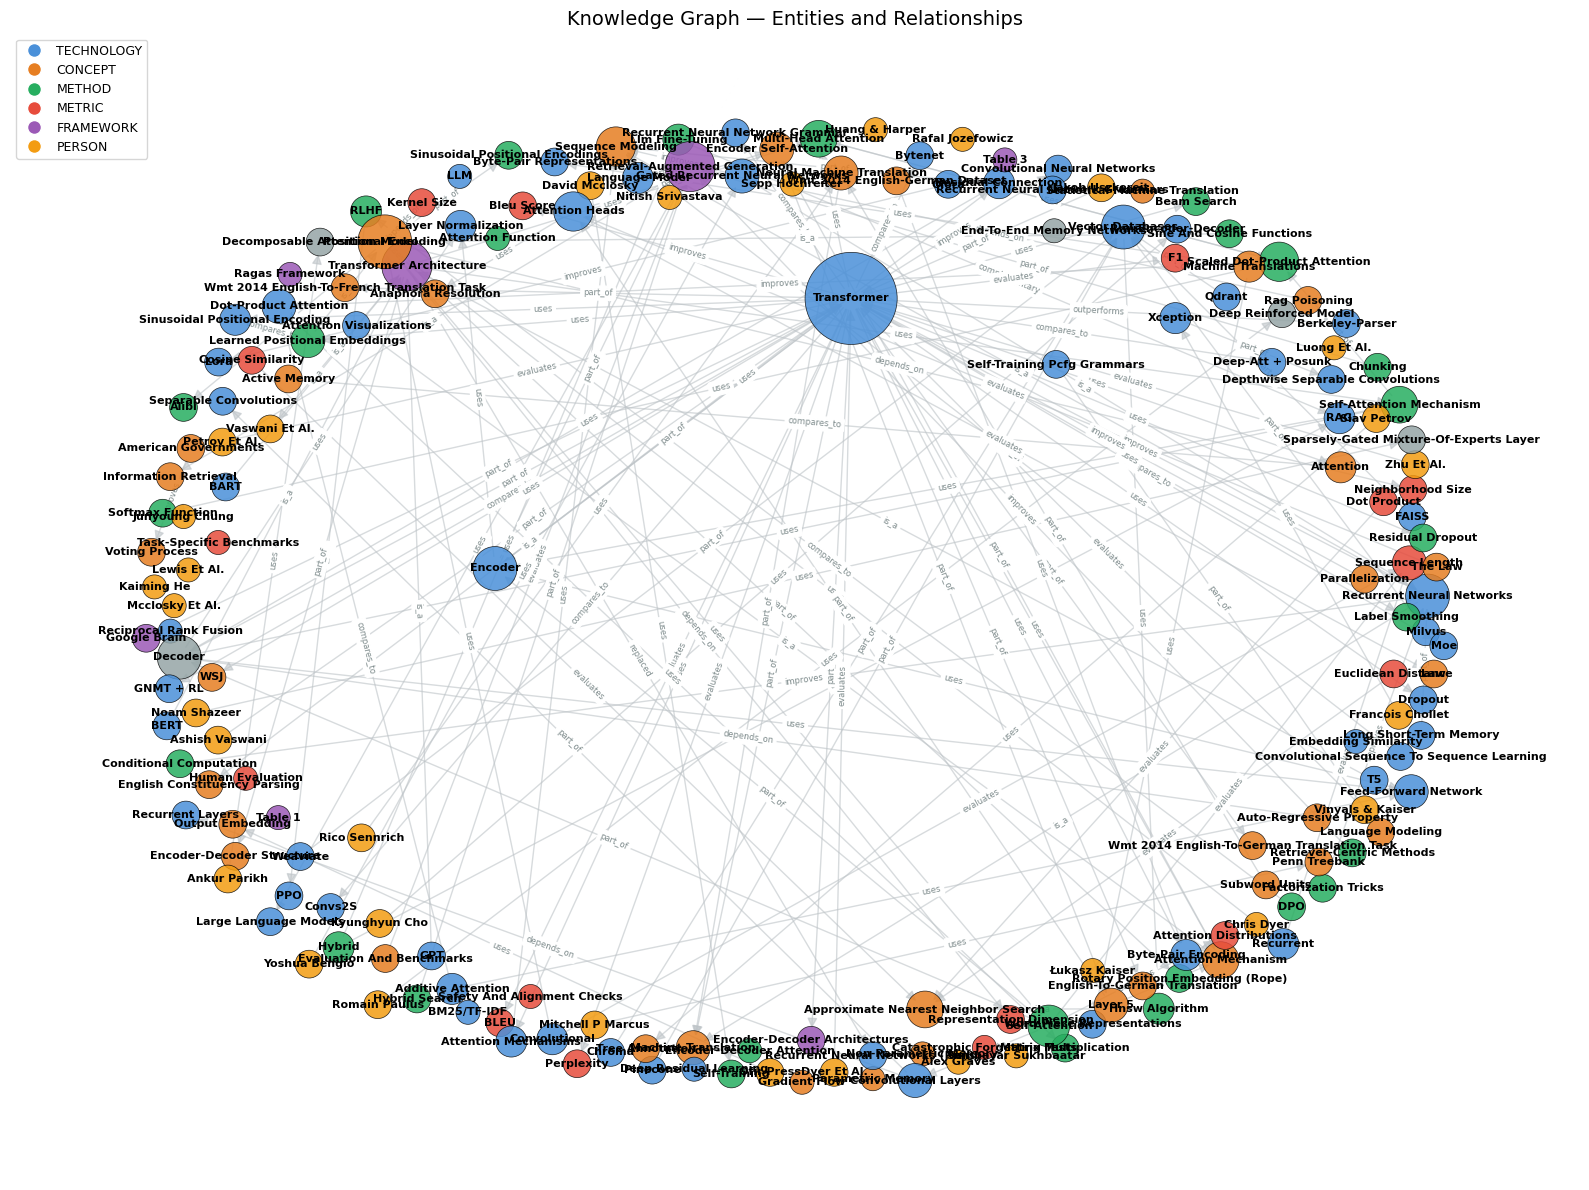

In [31]:
# ── Visualize the Knowledge Graph ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 12))

# Color nodes by type
type_colors = {
    "TECHNOLOGY": "#4A90D9",
    "CONCEPT": "#E67E22",
    "METHOD": "#27AE60",
    "METRIC": "#E74C3C",
    "FRAMEWORK": "#9B59B6",
    "PERSON": "#F39C12",
}

node_colors = [type_colors.get(kg.nodes[n].get("type", ""), "#95A5A6")
               for n in kg.nodes()]
node_sizes = [300 + 100 * kg.degree(n) for n in kg.nodes()]

pos = nx.spring_layout(kg, k=2.0, iterations=50, seed=42)

# Draw nodes
nx.draw_networkx_nodes(kg, pos, node_color=node_colors, node_size=node_sizes,
                        alpha=0.85, edgecolors="black", linewidths=0.5, ax=ax)

# Draw edges
nx.draw_networkx_edges(kg, pos, edge_color="#BDC3C7", arrows=True,
                        arrowsize=15, width=1.0, alpha=0.6, ax=ax)

# Draw labels
nx.draw_networkx_labels(kg, pos, font_size=8, font_weight="bold", ax=ax)

# Draw edge labels
edge_labels = {(u, v): d["relation"] for u, v, d in kg.edges(data=True)}
nx.draw_networkx_edge_labels(kg, pos, edge_labels, font_size=6,
                              font_color="#7F8C8D", ax=ax)

# Legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
               markersize=10, label=label)
    for label, color in type_colors.items()
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9)
ax.set_title("Knowledge Graph — Entities and Relationships", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

## Étape 3 — Détection de communautés et résumés

Microsoft GraphRAG introduit une idée clé : après extraction, le graphe est **segmenté en communautés** (algorithme de Leiden / Louvain) — sous-graphes densément connectés.

- Chaque communauté reçoit un **résumé LLM** (niveau local).
- Les communautés sont agrégées en **résumés globaux** (niveau corpus).
- Le retrieval route la question vers le **bon niveau** (local vs global).

Ici on utilise la **modularité** (NetworkX) comme approximation open-source de Leiden.

In [32]:
from networkx.algorithms.community import greedy_modularity_communities


def detect_communities(G: nx.DiGraph) -> List[set]:
    """Detect communities in the knowledge graph."""
    # Convert to undirected for community detection
    G_undirected = G.to_undirected()
    communities = list(greedy_modularity_communities(G_undirected))
    return communities


def summarize_community(G: nx.DiGraph, community: set) -> str:
    """Generate a text summary of a community's entities and relationships."""
    entities_info = []
    for node in community:
        data = G.nodes[node]
        entities_info.append(f"- {node} ({data.get('type', 'UNKNOWN')})")

    relations_info = []
    for u, v, data in G.edges(data=True):
        if u in community and v in community:
            relations_info.append(f"- {u} --[{data['relation']}]--> {v}")

    summary = f"Community with {len(community)} entities:\n"
    summary += "Entities:\n" + "\n".join(entities_info) + "\n"
    if relations_info:
        summary += "Relationships:\n" + "\n".join(relations_info)
    return summary


# Detect communities
communities = detect_communities(kg)
print(f"Detected {len(communities)} communities\n")

community_summaries = []
for i, comm in enumerate(communities):
    summary = summarize_community(kg, comm)
    community_summaries.append({"community_id": i, "entities": comm, "summary": summary})
    print(f"Community {i+1}: {sorted(comm)}")
    print(f"  Size: {len(comm)} entities")
    print()

Detected 55 communities

Community 1: ['Active Memory', 'Ashish Vaswani', 'Attention', 'BLEU', 'Beam Search', 'Berkeley-Parser', 'Bleu Score', 'Byte-Pair Encoding', 'Bytenet', 'Convolutional Neural Networks', 'Convs2S', 'Deep-Att + Posunk', 'Dropout', 'Dyer Et Al.', 'Encoder-Decoder Architectures', 'English Constituency Parsing', 'English-To-German Translation', 'F1', 'GNMT + RL', 'Google Brain', 'Jakob Uszkoreit', 'Label Smoothing', 'Learned Positional Embeddings', 'Moe', 'Parallelization', 'Perplexity', 'Petrov Et Al.', 'Recurrent Neural Network Grammar', 'Residual Dropout', 'Sinusoidal Positional Encoding', 'Transformer', 'Vinyals & Kaiser', 'WSJ', 'Wmt 2014 English-German Dataset', 'Wmt 2014 English-To-French Translation Task', 'Wmt 2014 English-To-German Translation Task', 'Zhu Et Al.']
  Size: 37 entities

Community 2: ['Alibi', 'Attention Distributions', 'Convolutional', 'Convolutional Layers', 'Kernel Size', 'Neighborhood Size', 'Positional Encoding', 'Recurrent', 'Recurrent La

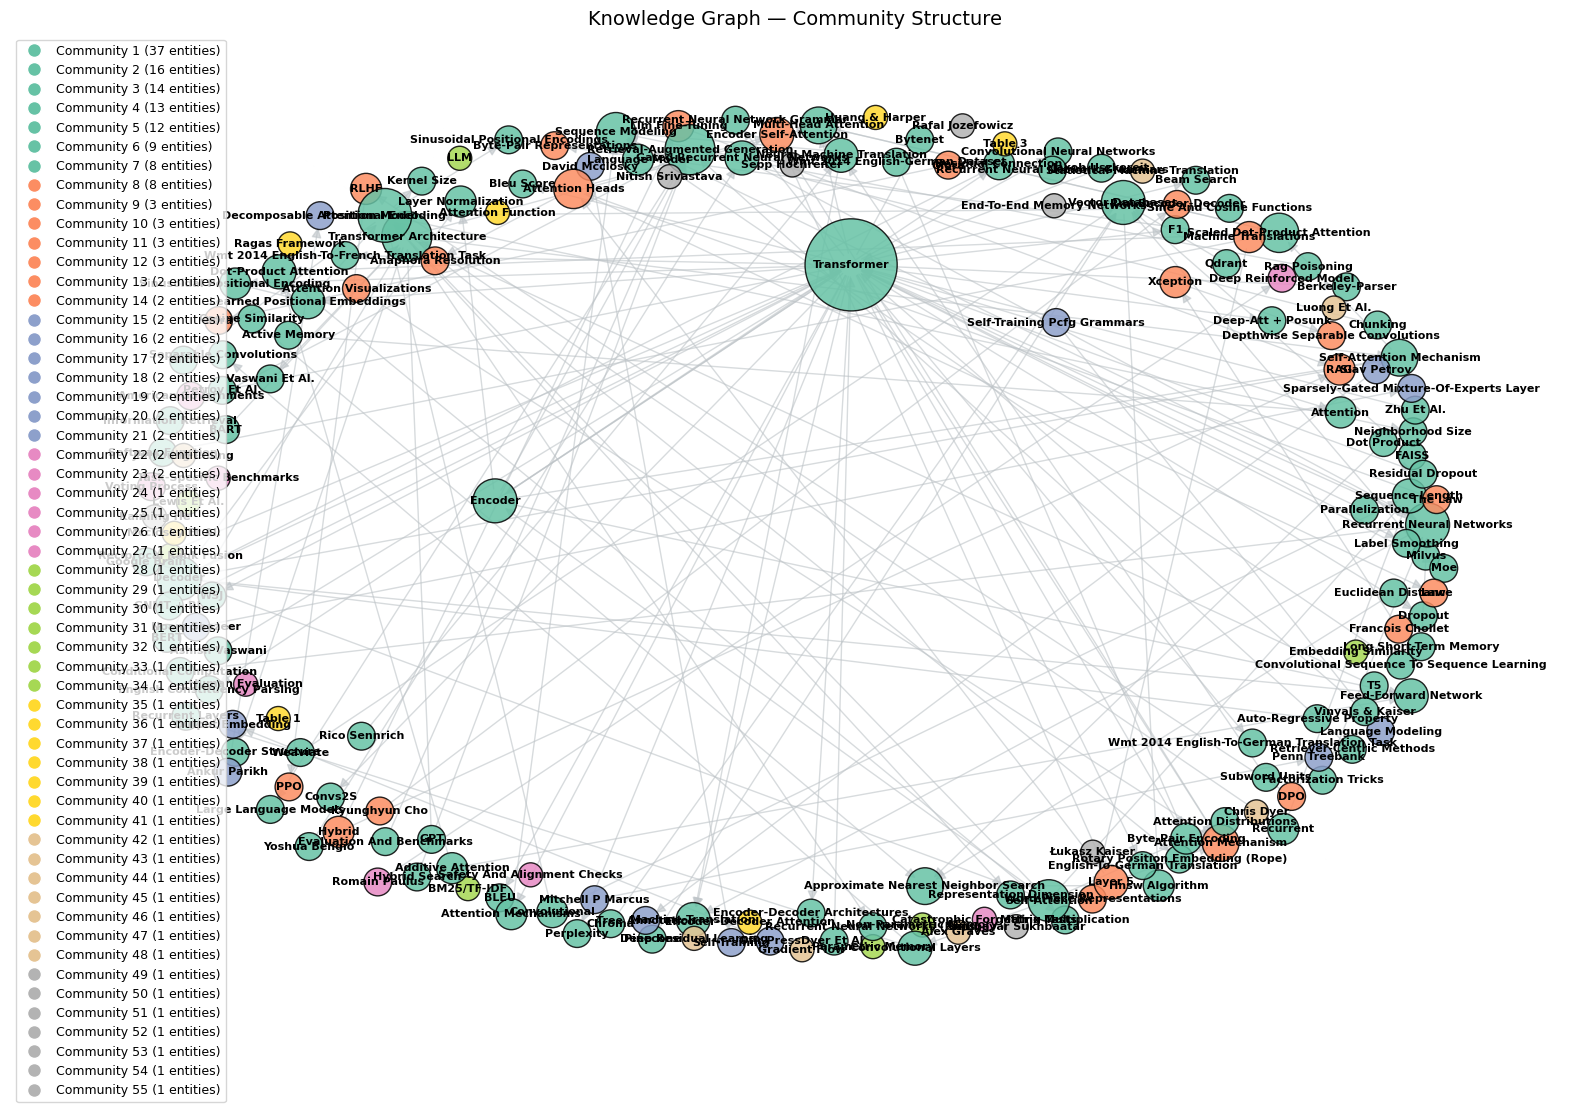

In [33]:
# ── Visualize communities ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 12))

# Assign colors by community
community_colors = plt.cm.Set2(np.linspace(0, 1, max(len(communities), 2)))
node_to_community = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_to_community[node] = i

node_colors_comm = [community_colors[node_to_community.get(n, 0)] for n in kg.nodes()]

nx.draw_networkx_nodes(kg, pos, node_color=node_colors_comm, node_size=node_sizes,
                        alpha=0.85, edgecolors="black", linewidths=1.0, ax=ax)
nx.draw_networkx_edges(kg, pos, edge_color="#BDC3C7", arrows=True,
                        arrowsize=15, width=1.0, alpha=0.6, ax=ax)
nx.draw_networkx_labels(kg, pos, font_size=8, font_weight="bold", ax=ax)

# Legend for communities
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=community_colors[i],
               markersize=10, label=f"Community {i+1} ({len(comm)} entities)")
    for i, comm in enumerate(communities)
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9)
ax.set_title("Knowledge Graph — Community Structure", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

## Étape 4 — Retrieval graphe : local vs global

Graph RAG supporte deux stratégies de retrieval :

| Stratégie | Fonctionnement | Idéal pour |
|-----------|---------------|------------|
| **Local** | Identifier les entités ancres dans la requête → traverser le voisinage 1–2 hops | Questions sur entité précise |
| **Global** | Router via les résumés de communautés → récupérer les clusters pertinents | Questions thématiques larges |

Nous implémentons les deux modes.

In [34]:
def find_anchor_entities(query: str, graph: nx.DiGraph, threshold: float = 0.4) -> List[str]:
    """Find entities mentioned in the query using embedding similarity."""
    query_emb = embed_model.encode([query], normalize_embeddings=True)
    node_names = list(graph.nodes())
    node_embs = embed_model.encode(node_names, normalize_embeddings=True)

    similarities = np.dot(query_emb, node_embs.T)[0]
    anchors = [(node_names[i], similarities[i])
               for i in range(len(node_names)) if similarities[i] > threshold]
    anchors.sort(key=lambda x: -x[1])
    return anchors


def retrieve_local_graph(query: str, graph: nx.DiGraph, hops: int = 2,
                          max_entities: int = 5) -> Dict:
    """Local graph retrieval: find anchor entities and traverse their neighborhood."""
    anchors = find_anchor_entities(query, graph)
    if not anchors:
        return {"entities": [], "triples": [], "context": "No relevant entities found."}

    # Collect neighborhood
    relevant_nodes = set()
    for anchor_name, _ in anchors[:max_entities]:
        if anchor_name in graph:
            relevant_nodes.add(anchor_name)
            # BFS up to `hops` steps
            for _ in range(hops):
                neighbors = set()
                for n in relevant_nodes:
                    neighbors.update(graph.successors(n))
                    neighbors.update(graph.predecessors(n))
                relevant_nodes.update(neighbors)

    # Collect triples from subgraph
    triples = []
    for u, v, data in graph.edges(data=True):
        if u in relevant_nodes and v in relevant_nodes:
            triples.append((u, data["relation"], v))

    # Build context string
    context_lines = [f"Entities: {', '.join(sorted(relevant_nodes))}"]
    context_lines.append("\nRelationships:")
    for s, r, o in triples:
        context_lines.append(f"  - {s} --[{r}]--> {o}")

    return {
        "entities": sorted(relevant_nodes),
        "triples": triples,
        "anchors": [(a, round(s, 3)) for a, s in anchors[:max_entities]],
        "context": "\n".join(context_lines),
    }


def retrieve_global_graph(query: str, communities: List[Dict],
                           top_k: int = 2) -> Dict:
    """Global graph retrieval: find relevant communities via summary similarity."""
    query_emb = embed_model.encode([query], normalize_embeddings=True)
    summaries = [c["summary"] for c in communities]
    summary_embs = embed_model.encode(summaries, normalize_embeddings=True)

    similarities = np.dot(query_emb, summary_embs.T)[0]
    top_indices = np.argsort(similarities)[::-1][:top_k]

    relevant_communities = []
    for idx in top_indices:
        relevant_communities.append({
            "community_id": communities[idx]["community_id"],
            "similarity": float(similarities[idx]),
            "summary": communities[idx]["summary"],
            "entities": communities[idx]["entities"],
        })

    context = "\n\n".join([
        f"[Community {c['community_id']+1}]\n{c['summary']}"
        for c in relevant_communities
    ])

    return {
        "communities": relevant_communities,
        "context": context,
    }


print("Graph retrieval functions defined.")

Graph retrieval functions defined.


In [35]:
# ── Test local graph retrieval ────────────────────────────────────────────
query = "How does the Transformer architecture relate to BERT and GPT?"
print(f"Query: '{query}'\n")

local_result = retrieve_local_graph(query, kg)
print(f"Anchor entities (with similarity):")
for name, score in local_result["anchors"]:
    print(f"  - {name} ({score:.3f})")

print(f"\nSubgraph: {len(local_result['entities'])} entities, "
      f"{len(local_result['triples'])} relationships")
print(f"\nContext for LLM:")
print(local_result["context"])

Query: 'How does the Transformer architecture relate to BERT and GPT?'

Anchor entities (with similarity):
  - Transformer Architecture (0.527)
  - BERT (0.471)
  - GPT (0.465)
  - Transformer (0.463)

Subgraph: 105 entities, 124 relationships

Context for LLM:
Entities: Active Memory, Additive Attention, Alibi, Anaphora Resolution, Ashish Vaswani, Attention, Attention Distributions, Attention Heads, Attention Mechanism, Attention Mechanisms, Attention Visualizations, Auto-Regressive Property, BART, BERT, BLEU, Beam Search, Berkeley-Parser, Bleu Score, Byte-Pair Encoding, Bytenet, Chunking, Conditional Computation, Convolutional, Convolutional Layers, Convolutional Neural Networks, Convolutional Sequence To Sequence Learning, Convs2S, Decoder, Deep-Att + Posunk, Dot-Product Attention, Dropout, Dyer Et Al., Encoder, Encoder Self-Attention, Encoder-Decoder Architectures, Encoder-Decoder Structure, English Constituency Parsing, English-To-German Translation, Evaluation And Benchmarks, F1,

In [36]:
# ── Test global graph retrieval ───────────────────────────────────────────
query = "What are the main evaluation approaches for AI systems?"
print(f"Query: '{query}'\n")

global_result = retrieve_global_graph(query, community_summaries)
for c in global_result["communities"]:
    print(f"Community {c['community_id']+1} (similarity: {c['similarity']:.3f}):")
    print(f"  Entities: {sorted(c['entities'])}")
    print()

Query: 'What are the main evaluation approaches for AI systems?'

Community 3 (similarity: 0.373):
  Entities: ['Attention Mechanisms', 'Conditional Computation', 'Convolutional Sequence To Sequence Learning', 'Factorization Tricks', 'Gated Recurrent Neural Networks', 'Long Short-Term Memory', 'Machine Translation', 'Neural Machine Translation', 'Recurrent Neural Network Grammars', 'Recurrent Neural Networks', 'Rico Sennrich', 'Sequence Modeling', 'Subword Units', 'Yoshua Bengio']

Community 6 (similarity: 0.332):
  Entities: ['Chunking', 'Evaluation And Benchmarks', 'Hybrid Search', 'Information Retrieval', 'Language Model', 'Large Language Models', 'Rag Poisoning', 'Retrieval-Augmented Generation', 'Retriever-Centric Methods']



## Étape 5 — Graph RAG hybride (graphe + vecteur)

L'approche la plus puissante combine :
- **Retrieval graphe** — structure relationnelle, multi-hop explicite
- **Retrieval vectoriel** — flexibilité sémantique, détails depuis le texte original

Le graphe fournit les relations structurées ; la base vectorielle remplit les détails depuis le texte. On fusionne au niveau du prompt.

In [37]:
def graph_rag_pipeline(query: str, graph: nx.DiGraph,
                        community_summaries: List[Dict],
                        top_k_vector: int = 3, top_k_graph: int = 3) -> Dict:
    """Full Graph RAG pipeline: graph + vector retrieval → augmented generation."""

    # 1. Local graph retrieval (entity neighborhood)
    local_result = retrieve_local_graph(query, graph)

    # 2. Global graph retrieval (community summaries)
    global_result = retrieve_global_graph(query, community_summaries, top_k=2)

    # 3. Vector retrieval (original chunk text)
    vector_results = retrieve_hybrid(query, top_k=top_k_vector)
    vector_reranked = rerank(query, vector_results, top_k=top_k_vector)

    # 4. Build combined prompt
    graph_context = (
        "=== Knowledge Graph Context ===\n"
        f"{local_result['context']}\n\n"
        "=== Community Summaries ===\n"
        f"{global_result['context']}"
    )

    vector_context = "\n\n---\n\n".join([
        f"[Chunk from {r['metadata'].get('source', '?')}]\n{r['text']}"
        for r in vector_reranked
    ])

    prompt = f"""You are an expert assistant with access to both a knowledge graph and document chunks.

Rules:
- Answer ONLY from the provided context (graph + documents).
- If evidence is insufficient, say: "Insufficient evidence in the provided context."
- Cite sources when possible.
- Leverage the knowledge graph for relationships between entities.
- Use document chunks for detailed explanations.

{graph_context}

=== Document Chunks ===
{vector_context}

Question: {query}

Answer:"""

    # 5. Generate
    answer = generate_answer(prompt)

    return {
        "query": query,
        "graph_entities": local_result["entities"],
        "graph_triples": local_result["triples"],
        "vector_chunks": len(vector_reranked),
        "prompt_tokens": count_tokens(prompt),
        "answer": answer,
    }


print("Graph RAG pipeline ready.")

Graph RAG pipeline ready.


In [38]:
# ── Test Graph RAG on relational questions ────────────────────────────────
graph_rag_queries = [
    "How does the Transformer architecture relate to BERT, GPT, and T5?",
    "What methods improve RAG retrieval quality?",
    "Compare LoRA and QLoRA for fine-tuning.",
    "What vector databases use HNSW and what are the alternatives?",
]

for q in graph_rag_queries:
    print(f"\n{'='*80}")
    print(f"Q: {q}")
    print(f"{'='*80}")

    result = graph_rag_pipeline(q, kg, community_summaries)

    print(f"\nGraph entities used: {result['graph_entities'][:8]}")
    print(f"Graph triples: {len(result['graph_triples'])} | "
          f"Vector chunks: {result['vector_chunks']} | "
          f"Prompt: {result['prompt_tokens']} tokens")
    print(f"\nAnswer:")
    print(result["answer"])


Q: How does the Transformer architecture relate to BERT, GPT, and T5?

Graph entities used: ['Active Memory', 'Additive Attention', 'Alibi', 'Anaphora Resolution', 'Ashish Vaswani', 'Attention', 'Attention Distributions', 'Attention Heads']
Graph triples: 124 | Vector chunks: 3 | Prompt: 4285 tokens

Answer:
The Transformer architecture is the foundation for several modern language models, including BERT, GPT, and T5. According to the provided context, specifically the [Chunk from transformers.md], BERT, GPT, and T5 are all variants of the Transformer architecture. 

- BERT is an encoder-only model based on the Transformer architecture.
- GPT is a decoder-only model based on the Transformer architecture.
- T5, along with BART, is an example of an encoder-decoder model based on the Transformer architecture.

This information is also supported by the relationships in the Knowledge Graph Context, where it is stated that BERT, GPT, and T5 are all "[is_a]--> Transformer Architecture". 

Th

---

## D.6 — Comparaison Vector RAG vs Graph RAG (sur les mêmes questions)

On compare comment **Vector RAG** (Partie A) et **Graph RAG** (Partie D) traitent les **mêmes** questions, avec un focus sur les questions **relationnelles** où le graphe est censé exceller.

### Tableau de décision (rappel)

| Type de question | Vector RAG | Graph RAG | Hybride (recommandé) |
|---|:---:|:---:|:---:|
| Factuelle isolée | ✅ | ⚠️ | ✅ |
| Résumé d'un document | ✅ | ⚠️ | ✅ |
| Multi-hop / relationnelle | ❌ | ✅ | ✅ |
| Requête globale sur corpus | ❌ | ✅ | ✅ |
| Paraphrases / synonymes | ✅ | ⚠️ | ✅ |

**Heuristique de routage :**
- *« Qui »*, *« quoi »*, *« combien »* isolés → **Vector**
- *« Comment X est lié à Y »*, *« tous les… »*, *« via Z »* → **Graph**
- En cas de doute, ou audience mixte → **Hybride** (notre `graph_rag_pipeline`)


In [39]:
# ── Side-by-side comparison ───────────────────────────────────────────────
comparison_queries = [
    # Relational question (Graph RAG should excel)
    "What is the relationship between Transformer, self-attention, and BERT?",
    # Factual question (Classic RAG should be sufficient)
    "What is the recommended chunk size for RAG systems?",
]

for q in comparison_queries:
    print(f"\n{'='*80}")
    print(f"Q: {q}")
    print(f"{'='*80}")

    # Classic RAG
    classic_result = rag_pipeline(q, retrieval_method="hybrid")
    print(f"\n--- Classic RAG ({classic_result['prompt_tokens']} tokens) ---")
    print(classic_result["answer"])

    # Graph RAG
    graph_result = graph_rag_pipeline(q, kg, community_summaries)
    print(f"\n--- Graph RAG ({graph_result['prompt_tokens']} tokens) ---")
    print(graph_result["answer"])


Q: What is the relationship between Transformer, self-attention, and BERT?

--- Classic RAG (1194 tokens) ---
The Transformer architecture introduced self-attention mechanisms [Source 1]. BERT is a modern variant of the Transformer, specifically an encoder-only model [Source 1]. This indicates that BERT utilizes self-attention, as it is based on the Transformer architecture.

--- Graph RAG (4048 tokens) ---
The Transformer architecture uses self-attention mechanisms, which replaced recurrent neural networks (RNNs). BERT is a type of Transformer architecture that is specifically an encoder-only model. According to the knowledge graph, BERT --[is_a]--> Transformer Architecture, indicating that BERT is a variant of the Transformer architecture. 

As stated in the document chunk from transformers.md, "Modern variants include encoder-only models (BERT), decoder-only models (GPT), and encoder-decoder models (T5, BART)." This shows that BERT is a specific implementation of the Transformer ar

## Analyse coût / bénéfice du Graph RAG

In [40]:
# ── Summarize the tradeoffs ───────────────────────────────────────────────
comparison_data = {
    "Aspect": [
        "Setup complexity",
        "Ingestion cost",
        "Handles relationships",
        "Simple factual Q&A",
        "Multi-hop reasoning",
        "Maintenance burden",
        "Retrieval latency",
    ],
    "Classic RAG": ["Low", "Low", "Weak", "Strong", "Weak", "Low", "Fast"],
    "Graph RAG": ["High", "High (LLM extraction)", "Strong", "Strong", "Strong", "High", "Medium"],
}

print(f"{'Aspect':<25} {'Classic RAG':<20} {'Graph RAG':<20}")
print(f"{'-'*65}")
for i in range(len(comparison_data["Aspect"])):
    print(f"{comparison_data['Aspect'][i]:<25} "
          f"{comparison_data['Classic RAG'][i]:<20} "
          f"{comparison_data['Graph RAG'][i]:<20}")

print("\nDecision rule:")
print("  Use Graph RAG when relational structure is CENTRAL to user questions.")
print("  Default to Classic RAG for simpler use cases — lower cost, faster iteration.")

Aspect                    Classic RAG          Graph RAG           
-----------------------------------------------------------------
Setup complexity          Low                  High                
Ingestion cost            Low                  High (LLM extraction)
Handles relationships     Weak                 Strong              
Simple factual Q&A        Strong               Strong              
Multi-hop reasoning       Weak                 Strong              
Maintenance burden        Low                  High                
Retrieval latency         Fast                 Medium              

Decision rule:
  Use Graph RAG when relational structure is CENTRAL to user questions.
  Default to Classic RAG for simpler use cases — lower cost, faster iteration.


---

# Synthèse et livrables

## Ce que vous avez construit

| Étape | Ce que vous avez fait | Brique LangChain | Enseignement clé |
|---|---|---|---|
| **Loading** | PDF, Markdown, Web → `Document` uniformes | `PyPDFLoader`, `WebBaseLoader`, `UnstructuredMarkdownLoader` | Métadonnées critiques pour le filtrage et la citation |
| **Chunking** | Récursif tokens + structure Markdown + Contextual Retrieval | `RecursiveCharacterTextSplitter`, `MarkdownHeaderTextSplitter` | Chunking = levier qualité n°1 |
| **Embeddings** | Bi-encoder (MiniLM) + démo similarité | `sentence-transformers` | Open-source, normaliser pour cosine = dot |
| **Vector Storage** | Chroma + BM25 (HNSW vs IVF expliqué) | `chromadb`, `rank_bm25` | Hybride par défaut en prod |
| **Retrieval** | Dense / Sparse / Hybride (RRF) | — | RRF surpasse régulièrement les méthodes seules |
| **Reranking** | Cross-encoder (vs Bi-encoder expliqué) | `sentence-transformers/CrossEncoder` | +10 à +30 % Faithfulness à coût modéré |
| **Génération** | `llama-3.3-70b-versatile` via Groq (Python pur) | — | API OpenAI-compatible, gratuit, ultra-rapide |
| **Advanced** | Lost-in-the-middle, Query Rewriting, Multi-Query, HyDE | — | À combiner selon les types de requêtes |
| **Évaluation** | RAGas (Faithfulness, Relevancy, Precision, Recall) | `ragas` + `langchain-groq` | LLM-as-a-judge — itératif et mesurable |
| **Observabilité** | Trace LangSmith (cellule prête) | `langsmith` | 80 % des bugs = retrieval invisible |
| **Graph RAG (bonus)** | Extraction → KG → communautés → retrieval local/global | `networkx` | Supérieur sur les questions relationnelles |

## Principes clés

1. **« Garbage retrieval in, garbage answer out. »** La qualité du retrieval **borne** la qualité de la réponse.
2. **Chunker intelligemment.** Les plus gros gains viennent du chunking + reranking, pas du LLM.
3. **L'orchestration en Python pur, c'est la transparence.** LangChain pour les briques, pas pour l'orchestration.
4. **Évaluer en continu.** Golden set + RAGas + LangSmith = le triptyque indispensable.
5. **L'hybride est le standard.** Sparse + dense + reranker = baseline production.
6. **Graph RAG quand c'est nécessaire.** Puissant pour les relations, overkill pour les FAQ simples.

## Livrables attendus (par participant)

- **Notebook versionné** avec les parties A, B, C exécutées (D si le temps le permet).
- **Résultats RAGas** sur leur **propre corpus** (3-5 questions golden set).
- **Mini rapport** (5-10 lignes) : leur cas d'usage, l'approche choisie (Basic / Advanced / Graph), les métriques observées.
- **Au moins une technique Advanced testée** (Multi-Query OU HyDE OU Contextual Retrieval).

## Critères d'évaluation

- Qualité du pipeline (chunking, embeddings, retrieval).
- Pertinence des choix (modèle d'embedding adapté ? hybrid utile ? reranker activé ?).
- Sérieux de l'évaluation (golden set représentatif, métriques RAGas mesurées).
- Justification du choix final pour leur cas d'usage.
- Prise en compte de la sécurité / gouvernance des données.

## Exercices pour aller plus loin

1. **Réglage de `chunk_size`** ∈ {128, 256, 512, 1024} → mesurer Context Precision / Recall avec RAGas.
2. **Comparer 2 modèles d'embedding** : `all-MiniLM-L6-v2` (384D, EN) vs `multilingual-e5-large` (1024D, multilingue) sur un corpus FR.
3. **Activer Multi-Query + HyDE en cascade** sur les requêtes courtes (< 5 mots) uniquement.
4. **Filtrage par métadonnées** au retrieval : `where={"format": "pdf", "year": "2024"}`.
5. **Cache sémantique** : indexer les paires (question_emb, réponse). Si une nouvelle requête a un cosinus > 0.95 avec une question existante, renvoyer la réponse cachée.
6. **Routeur agentique** : un classifieur LLM décide, par requête, quoi activer (Multi-Query ? HyDE ? Graph ?).
7. **Étendre le graphe** (Partie D) : ajouter 5 nouveaux PDF, observer la croissance des communautés.
8. **Tester un autre modèle Groq** : remplacer `llama-3.3-70b-versatile` par `llama-3.1-8b-instant` (plus rapide, moins précis) ou `mixtral-8x7b-32768` — comparer Faithfulness.

---

## Transition vers le Jour 3

> *Aujourd'hui, vos RAG sont **statiques** : on les interroge, ils répondent. Demain (Jour 3 — TP 4), on construit un **AI Research Assistant** :*
>
> - *un **agent ReAct en Python avec LangChain**, qui appelle votre RAG via `retriever.as_tool()`, plus Tavily (web) et arXiv ;*
> - *un **Adaptive RAG en LangGraph** (grade docs → rewrite ; grade answer → web fallback) ;*
> - *le même use case en **no-code via n8n** pour comparer code vs no-code.*
